# 03 · 回测与可视化 Cheat Sheet

从最简单的 `仓位 × 收益` 开始，按成交时点、账户记账方法和数据形状选择模板。

每个案例都按 **`display(df)` 输入表 → 场景与任务 → 回测代码与结果表 → `plt.*` 图 → 解读** 排列。
先读小表，确定自己的列表示什么，再复制代码。所有案例都能独立运行，不需要先执行前面的案例。

1. 运行一次下面的初始化格。
2. 找到 B01–B18 中适合的案例；练习时运行它的示例建表格。
3. 已有数据时跳过示例建表，先 `display(df.head())` 检查字段，再运行该例的回测格和绘图格。
4. 先用小表核对一两笔金额，再换完整数据；示例的 `assert` 帮你发现错位或不符合假设的输入。

这里把已有的 position / score 当作输入；**不把构造策略、调参和回测收益混为一件事**。
B14 展示时间划分与阈值选择，完整机器学习建模不属于本册。
数据均为合成教学小表，没有策略盈利证据。图内用英文避免字体缺失，解释与注释使用中文。

## 先决定用哪一种记账

| 你拿到什么 / 想做什么 | 对应案例 |
|---|---|
| 一列价格、一列目标仓位，成交前已知仓位 | B01 收盘→收盘 |
| 收盘后才有信号，下一开盘执行 | B02 开盘→开盘 |
| 当天开盘前已知信号、收盘全部退出 | B03 当日开→收 |
| 不规则日内时间戳，允许跨夜 | B04 逐bar→逐日复合 |
| 要认真算换手和交易费 | B05 现金/股数/费后目标权重 |
| 多资产价格和权重，宽表或长表 | B06 / B07 |
| 每周等指定日期再平衡，其余时间不交易 | B08 固定股数与权重漂移 |
| 每次固定投入金额，不按账户权益复投 | B09 固定本金PnL |
| 已有 buy/hold/sell 指令 | B10 事件驱动账户 |
| 两条腿的配对策略 | B11 双腿贡献 |
| 每天新开一笔、每笔持有3期 | B12 独立分批账户 |
| 按历史波动调整仓位 | B13 风险目标 |
| 选参数并报告真正未见的测试结果 | B14 时间切分 |
| 已有每日净收益，需要指标与回撤图 | B15 |
| 月度汇报、对照基准与滚动风险、费用敏感性 | B16 / B17 / B18 |

## 三种时序，别机械地加 shift

| 已知信息与成交约定 | 本行收益区间 | 对应仓位 |
|---|---|---|
| t−1 收盘成交前确定权重，按该收盘成交 | `close[t] / close[t-1] - 1` | `position.shift(1)` |
| t−2 收盘后产生信号，t−1 开盘成交 | `open[t] / open[t-1] - 1` | `close_signal.shift(2)` |
| t 开盘前确定仓位，当天开仓并平仓 | `close[t] / open[t] - 1` | 当行 `position` |

`shift` 移动的是观测行，不能自动保证可交易，也不自动代表自然日。你需要先写出“信号可用 → 成交 → 估值”的时间线。

**共同单位：** 收益 0.01 = 1%；仓位是相对于账户权益的资金比例；单边 1 bp = 0.0001。
`pnl` 是货币金额，`return` 是收益率；账户净值是 `equity / initial_cash`。
无费用向量化案例假定在每个指定时点再平衡，现金利息为 0；它们不是固定股数持有。

In [1]:
# SETUP：只运行一次；每个case仍然有自己的输入df。
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BLUE, TEAL, RED, ORANGE = '#2563EB', '#0F766E', '#DC2626', '#D97706'
plt.rcdefaults()
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'figure.dpi': 120, 'savefig.dpi': 180,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'axes.grid.axis': 'y', 'axes.axisbelow': True,
    'grid.color': '#E2E8F0', 'grid.alpha': 0.8,
    'axes.titlelocation': 'left', 'axes.titleweight': 'bold',
    'axes.titlesize': 13, 'axes.titlepad': 14,
    'lines.linewidth': 2, 'legend.frameon': False,
})

<a id='B01'></a>
## B01 · 单资产：收盘成交，赚取下一段收盘到收盘收益

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [2]:
df = pd.DataFrame({
    "date": pd.bdate_range("2024-01-02", periods=8),
    "close": [100, 102, 101, 104, 103, 105, 102, 104],
    "position": [1.0, 1.0, 0.5, 0.0, 1.0, 0.5, 0.0, 0.0],
})
display(df)

,date,close,position
0,2024-01-02,100,1.0
1,2024-01-03,102,1.0
2,2024-01-04,101,0.5
3,2024-01-05,104,0.0
4,2024-01-08,103,1.0
5,2024-01-09,105,0.5
6,2024-01-10,102,0.0
7,2024-01-11,104,0.0


**场景 / 要做什么：**

close 是每日收盘价；position 是当天收盘成交后希望持有的目标资金权重，1=满仓、0=空仓。这里假定 position 在该收盘成交前已经确定，且能按收盘价成交。每天收盘按目标权重再平衡；截至当天收盘的收益由上一行 position 决定，所以 shift(1)。首行开始前为空仓。若信号只能等当天收盘后才能算出，请用 B02。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [3]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and df["date"].is_unique
assert np.isfinite(df[["close", "position"]].to_numpy()).all()
assert (df["close"] > 0).all() and df["position"].between(0, 1).all()

# 当天的资产收益，来自上一收盘到当前收盘；首行没有前值。
df["asset_ret"] = df["close"].pct_change(fill_method=None)
df["held_weight"] = df["position"].shift(1, fill_value=0)
df["strategy_ret"] = df["held_weight"] * df["asset_ret"]
df.loc[0, "strategy_ret"] = 0.0  # 首行前没有持仓，不是补齐缺失行情。
df["nav"] = (1 + df["strategy_ret"]).cumprod()
display(df[["date", "close", "position", "held_weight", "asset_ret", "strategy_ret", "nav"]].round(4))

,date,close,position,held_weight,asset_ret,strategy_ret,nav
0,2024-01-02,100,1.0,0.0,NaN,0.0000,1.0000
1,2024-01-03,102,1.0,1.0,0.0200,0.0200,1.0200
2,2024-01-04,101,0.5,1.0,-0.0098,-0.0098,1.0100
3,2024-01-05,104,0.0,0.5,0.0297,0.0149,1.0250
4,2024-01-08,103,1.0,0.0,-0.0096,-0.0000,1.0250
5,2024-01-09,105,0.5,1.0,0.0194,0.0194,1.0449
6,2024-01-10,102,0.0,0.5,-0.0286,-0.0143,1.0300
7,2024-01-11,104,0.0,0.0,0.0196,0.0000,1.0300


**可视化：** 直接使用刚刚算出的结果。

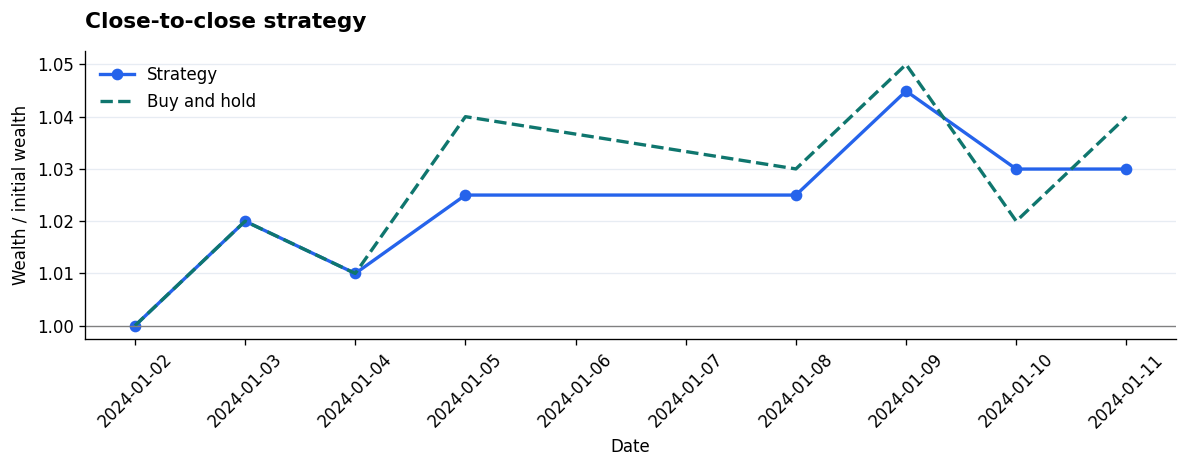

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["nav"], color=BLUE, marker="o", label="Strategy")
plt.plot(df["date"], df["close"] / df["close"].iloc[0], color=TEAL, linestyle="--", label="Buy and hold")
plt.axhline(1, color="grey", linewidth=0.8)
plt.title("Close-to-close strategy")
plt.xlabel("Date")
plt.ylabel("Wealth / initial wealth")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**怎么看：** 先在结果表中对照 position 和 held_weight：今天把 position 改为0，不会取消已经持仓经过的上一段收益。图中的两条线从相同资金起点比较。

**换数据时注意：** 本例忽略费用、滑点和现金利息；position 是每天重新设置的目标权重，不是固定股数。价格应包含一致的分红/拆股处理；最后一行的新持仓尚无下一段收益。示例权重只是演示记账，不能解释为有效策略。

<a id='B02'></a>
## B02 · 收盘后生成信号：下一期开盘成交，按开盘到开盘结算

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [5]:
df = pd.DataFrame({
    "date": pd.bdate_range("2024-01-02", periods=8),
    "open": [100, 102, 101, 104, 102, 105, 103, 106],
    "close_signal": [1.0, 0.5, 0.0, 1.0, 1.0, 0.5, 0.0, 1.0],
})
display(df)

,date,open,close_signal
0,2024-01-02,100,1.0
1,2024-01-03,102,0.5
2,2024-01-04,101,0.0
3,2024-01-05,104,1.0
4,2024-01-08,102,1.0
5,2024-01-09,105,0.5
6,2024-01-10,103,0.0
7,2024-01-11,106,1.0


**场景 / 要做什么：**

open 是当天开盘价；close_signal 是当天收盘后才能知道的目标权重。t日收盘的信号在t+1日开盘成交，从t+1开盘持有到t+2开盘，因此归属t+2行的开盘到开盘收益要乘 close_signal.shift(2)。这里统一在开盘时点观察账户，不混用收盘估值。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [6]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and df["date"].is_unique
assert np.isfinite(df[["open", "close_signal"]].to_numpy()).all()
assert (df["open"] > 0).all() and df["close_signal"].between(0, 1).all()

# execute_weight 是此刻开盘成交后仓位；held_weight 是刚结束区间的仓位。
df["execute_weight"] = df["close_signal"].shift(1, fill_value=0)
df["held_weight"] = df["close_signal"].shift(2, fill_value=0)
df["open_to_open_ret"] = df["open"].pct_change(fill_method=None)
df["strategy_ret"] = df["held_weight"] * df["open_to_open_ret"]
df.loc[0, "strategy_ret"] = 0.0  # 数据开始前为空仓。
df["nav"] = (1 + df["strategy_ret"]).cumprod()
display(df[["date", "open", "close_signal", "execute_weight", "held_weight", "open_to_open_ret", "strategy_ret", "nav"]].round(4))

,date,open,close_signal,execute_weight,held_weight,open_to_open_ret,strategy_ret,nav
0,2024-01-02,100,1.0,0.0,0.0,NaN,0.0000,1.0000
1,2024-01-03,102,0.5,1.0,0.0,0.0200,0.0000,1.0000
2,2024-01-04,101,0.0,0.5,1.0,-0.0098,-0.0098,0.9902
3,2024-01-05,104,1.0,0.0,0.5,0.0297,0.0149,1.0049
4,2024-01-08,102,1.0,1.0,0.0,-0.0192,-0.0000,1.0049
5,2024-01-09,105,0.5,1.0,1.0,0.0294,0.0294,1.0345
6,2024-01-10,103,0.0,0.5,1.0,-0.0190,-0.0190,1.0148
7,2024-01-11,106,1.0,0.0,0.5,0.0291,0.0146,1.0295


**可视化：** 直接使用刚刚算出的结果。

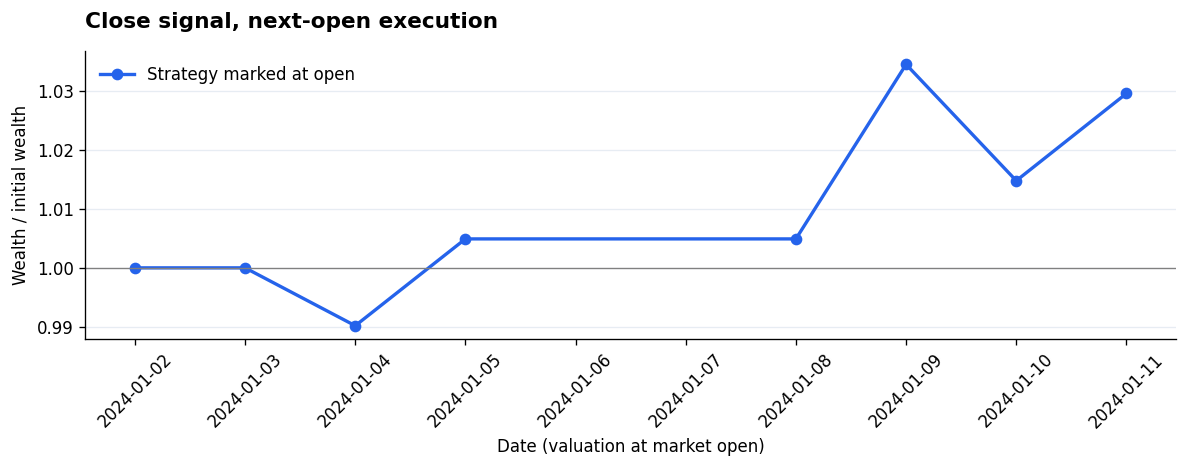

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["nav"], color=BLUE, marker="o", label="Strategy marked at open")
plt.axhline(1, color="grey", linewidth=0.8)
plt.title("Close signal, next-open execution")
plt.xlabel("Date (valuation at market open)")
plt.ylabel("Wealth / initial wealth")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**怎么看：** 第1行收盘信号为1，在第2行开盘执行，到第3行开盘才记录它赚取的完整区间收益。因此开头两行策略收益都是0。结果中的执行权重与收益归属权重相差一行。

**换数据时注意：** shift(2) 只适用于本例的信号时间和收益标签定义，不能机械套用。最后一行信号还没有下一开盘，无法执行；倒数第2行信号虽在最后开盘执行，也没有后续开盘估值。本例忽略费用，并假设信号在下一开盘前已可交易。

<a id='B03'></a>
## B03 · 日内交易：开盘建仓、收盘平仓，隔夜空仓

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [8]:
df = pd.DataFrame({
    "date": pd.bdate_range("2024-01-02", periods=8),
    "open": [100, 102, 101, 104, 102, 105, 103, 106],
    "close": [101, 101, 103, 103, 104, 104, 106, 105],
    "position": [1.0, 0.5, -0.5, 0.0, 1.0, -1.0, 0.5, 0.0],
})
display(df)

,date,open,close,position
0,2024-01-02,100,101,1.0
1,2024-01-03,102,101,0.5
2,2024-01-04,101,103,-0.5
3,2024-01-05,104,103,0.0
4,2024-01-08,102,104,1.0
5,2024-01-09,105,104,-1.0
6,2024-01-10,103,106,0.5
7,2024-01-11,106,105,0.0


**场景 / 要做什么：**

open/close 是同一天的开/收盘价；position 是当天开盘前已知的资金权重，正数做多、负数做空。每天按开盘价建仓，按当天收盘价全部平仓，隔夜没有持仓。因为position已与要交易的当天对齐，直接乘当天open-to-close收益，不再shift。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [9]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and df["date"].is_unique
assert np.isfinite(df[["open", "close", "position"]].to_numpy()).all()
assert (df[["open", "close"]] > 0).all().all()
assert df["position"].between(-1, 1).all()

# 每日开盘使用当前账户资金确定交易名义金额，收盘后全回现金。
df["intraday_ret"] = df["close"] / df["open"] - 1
df["strategy_ret"] = df["position"] * df["intraday_ret"]
assert (1 + df["strategy_ret"] > 0).all(), "账户耗尽时应停止回测并处理清算"
df["nav"] = (1 + df["strategy_ret"]).cumprod()
display(df[["date", "open", "close", "position", "intraday_ret", "strategy_ret", "nav"]].round(4))

,date,open,close,position,intraday_ret,strategy_ret,nav
0,2024-01-02,100,101,1.0,0.0100,0.0100,1.0100
1,2024-01-03,102,101,0.5,-0.0098,-0.0049,1.0050
2,2024-01-04,101,103,-0.5,0.0198,-0.0099,0.9951
3,2024-01-05,104,103,0.0,-0.0096,-0.0000,0.9951
4,2024-01-08,102,104,1.0,0.0196,0.0196,1.0146
5,2024-01-09,105,104,-1.0,-0.0095,0.0095,1.0243
6,2024-01-10,103,106,0.5,0.0291,0.0146,1.0392
7,2024-01-11,106,105,0.0,-0.0094,-0.0000,1.0392


**可视化：** 直接使用刚刚算出的结果。

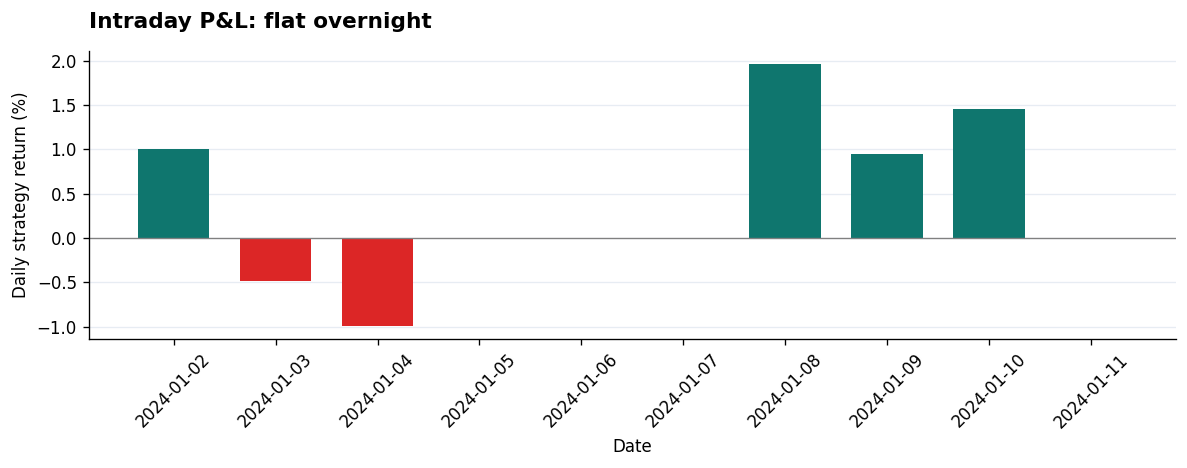

In [10]:
plt.figure(figsize=(10, 4))
plt.bar(df["date"], df["strategy_ret"] * 100,
        color=np.where(df["strategy_ret"] >= 0, TEAL, RED), width=0.7)
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Intraday P&L: flat overnight")
plt.xlabel("Date")
plt.ylabel("Daily strategy return (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**怎么看：** 看负的position遇到价格下跌时是否产生正收益。柱图每根柱子对应一次日内交易日的资金收益；position=0时不参与当天价格变化。

**换数据时注意：** 必须确认position真的在开盘前可知，不能根据当天close反推。本例忽略每天开仓和平仓的两边费用、滑点、借券费和做空约束；隔夜跳空不属于本策略收益。

<a id='B04'></a>
## B04 · 不规则日内bar：先逐段记账，再复合为每日收益

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [11]:
df = pd.DataFrame({
    "timestamp": ["2024-01-02 09:30", "2024-01-02 10:40", "2024-01-02 16:00",
                  "2024-01-03 09:30", "2024-01-03 11:15", "2024-01-03 16:00",
                  "2024-01-04 09:30", "2024-01-04 13:10", "2024-01-04 16:00"],
    "price": [100, 101, 102, 99, 100, 103, 104, 102, 105],
    "position": [1.0, 0.5, 0.5, 1.0, 0.0, 1.0, 0.5, 1.0, 0.0],
})
display(df)

,timestamp,price,position
0,2024-01-02 09:30,100,1.0
1,2024-01-02 10:40,101,0.5
2,2024-01-02 16:00,102,0.5
3,2024-01-03 09:30,99,1.0
4,2024-01-03 11:15,100,0.0
5,2024-01-03 16:00,103,1.0
6,2024-01-04 09:30,104,0.5
7,2024-01-04 13:10,102,1.0
8,2024-01-04 16:00,105,0.0


**场景 / 要做什么：**

timestamp 是同一个市场的本地时刻，price是该时点成交/估值价格；position在该时点成交前已知。bar的间隔可以不同；用上一时点仓位乘相邻价格收益。本例允许跨夜持仓，所以前一天16:00到次日09:30的变化也计入次日收益。最后按本地自然日复合，不把bar收益直接相加。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"]).dt.tz_localize("Asia/Hong_Kong")
df = df.sort_values("timestamp").reset_index(drop=True)
assert df["timestamp"].notna().all() and df["timestamp"].is_unique
assert np.isfinite(df[["price", "position"]].to_numpy()).all()
assert (df["price"] > 0).all() and df["position"].between(0, 1).all()

df["bar_ret"] = df["price"].pct_change(fill_method=None)
df["held_weight"] = df["position"].shift(1, fill_value=0)
df["strategy_ret"] = df["held_weight"] * df["bar_ret"]
df.loc[0, "strategy_ret"] = 0.0
df["date"] = df["timestamp"].dt.normalize()
daily = (1 + df["strategy_ret"]).groupby(df["date"]).prod().sub(1).to_frame("daily_ret")
daily["nav"] = (1 + daily["daily_ret"]).cumprod()
display(df[["timestamp", "price", "held_weight", "bar_ret", "strategy_ret"]].round(4))
display(daily.round(4))

,timestamp,price,held_weight,bar_ret,strategy_ret
0,2024-01-02 09:30:00+08:00,100,0.0,NaN,0.0000
1,2024-01-02 10:40:00+08:00,101,1.0,0.0100,0.0100
2,2024-01-02 16:00:00+08:00,102,0.5,0.0099,0.0050
3,2024-01-03 09:30:00+08:00,99,0.5,-0.0294,-0.0147
4,2024-01-03 11:15:00+08:00,100,1.0,0.0101,0.0101
5,2024-01-03 16:00:00+08:00,103,0.0,0.0300,0.0000
6,2024-01-04 09:30:00+08:00,104,1.0,0.0097,0.0097
7,2024-01-04 13:10:00+08:00,102,0.5,-0.0192,-0.0096
8,2024-01-04 16:00:00+08:00,105,1.0,0.0294,0.0294


,daily_ret,nav
date,,
2024-01-02 00:00:00+08:00,0.0150,1.0150
2024-01-03 00:00:00+08:00,-0.0048,1.0102
2024-01-04 00:00:00+08:00,0.0294,1.0399


**可视化：** 直接使用刚刚算出的结果。

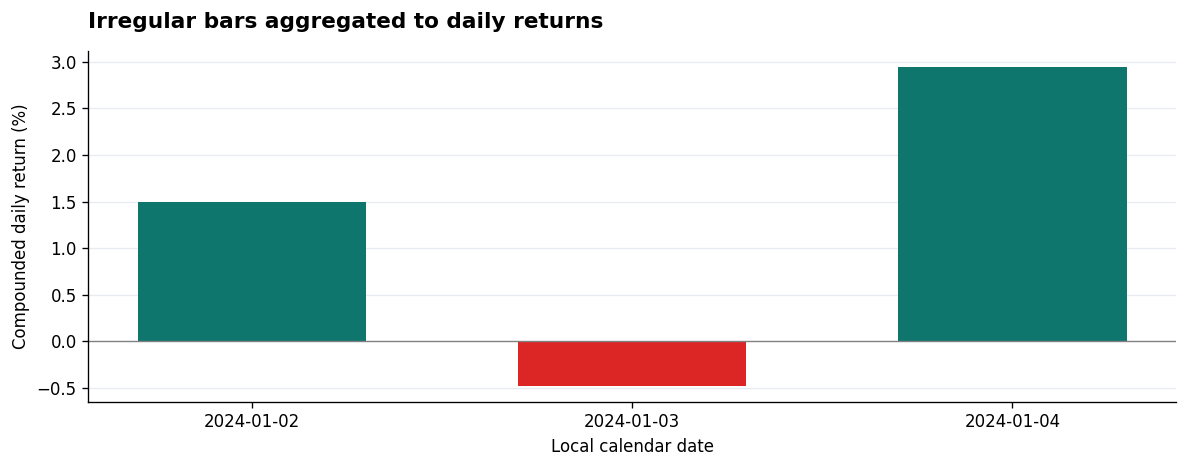

In [13]:
plt.figure(figsize=(10, 4))
plt.bar(daily.index, daily["daily_ret"] * 100,
        color=np.where(daily["daily_ret"] >= 0, TEAL, RED), width=0.6)
plt.axhline(0, color="grey", linewidth=0.8)
plt.title("Irregular bars aggregated to daily returns")
plt.xlabel("Local calendar date")
plt.ylabel("Compounded daily return (%)")
plt.xticks(daily.index, daily.index.strftime("%Y-%m-%d"))
plt.tight_layout()
plt.show()

**怎么看：** 逐bar表展示收益具体来自哪个区间；每日表把属于同一天的这些区间按(1+r)连乘。隔夜跳空被计入区间终点所在日，因此早盘那根bar不只是开盘后的收益。

**换数据时注意：** 不按bar数直接套sqrt(252)或假设每bar等时长。这里自然日正好对应示例交易日；期货夜盘应使用交易所session标签分组。缺失行情先查原因，不能任意补0；本例默认相邻记录间持续持仓、首日从09:30开始，不含更早区间，且每个记录时点再平衡。

<a id='B05'></a>
## B05 · 真实成交费用：用现金和股数记账，精确调整目标权重

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [14]:
df = pd.DataFrame({
    "date": pd.bdate_range("2024-01-02", periods=8),
    "close": [100, 102, 101, 104, 103, 105, 102, 104],
    "target_weight": [0.8, 0.8, 0.4, 0.4, 0.9, 0.9, 0.4, 0.0],
})
display(df)

,date,close,target_weight
0,2024-01-02,100,0.8
1,2024-01-03,102,0.8
2,2024-01-04,101,0.4
3,2024-01-05,104,0.4
4,2024-01-08,103,0.9
5,2024-01-09,105,0.9
6,2024-01-10,102,0.4
7,2024-01-11,104,0.0


**场景 / 要做什么：**

close是执行和估值价格；target_weight是当日收盘成交前已知的、费后账户权益中股票应占比例，范围0到1。每个时点先按现价估值，再交易到目标；手续费=实际买入或卖出名义金额×fee_rate。本例允许小数股，初始资金10000、单边费率10bp，最后目标为0表示平仓。用cash/shares可正确处理价格引起的权重漂移：目标不变时也可能有交易。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [15]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and df["date"].is_unique
assert np.isfinite(df[["close", "target_weight"]].to_numpy()).all()
assert (df["close"] > 0).all() and df["target_weight"].between(0, 1).all()
initial_cash, fee_rate = 10000.0, 0.001
cash, shares = initial_cash, 0.0
records = []

for row in df.itertuples(index=False):
    old_stock_value = shares * row.close
    equity_before = cash + old_stock_value  # 交易前按当前价格估值
    w = row.target_weight
    gap = w * equity_before - old_stock_value
    # 解 trade = w * (equity_before - fee_rate * abs(trade)) - old_stock_value。
    # trade>0买入，trade<0卖出；保证最终股票权重等于w，而非费用前近似。
    trade = gap / (1 + w * fee_rate) if gap >= 0 else gap / (1 - w * fee_rate)
    cost = abs(trade) * fee_rate
    shares += trade / row.close
    cash -= trade + cost
    equity = cash + shares * row.close
    assert equity > 0 and cash >= -1e-8
    records.append([cash, shares, trade, cost, abs(trade) / equity_before, equity])

result = pd.DataFrame(records, columns=["cash", "shares", "trade_value", "cost", "turnover", "equity"])
result = pd.concat([df, result], axis=1)
# 第一行费用不能丢：分母用初始资金，而不是第一行交易后的equity。
result["period_ret"] = result["equity"] / result["equity"].shift(1, fill_value=initial_cash) - 1
result["nav"] = result["equity"] / initial_cash
result["drawdown"] = result["equity"] / result["equity"].cummax().clip(lower=initial_cash) - 1
result["actual_weight"] = result["shares"] * result["close"] / result["equity"]
assert np.allclose(result["actual_weight"], result["target_weight"])
display(result[["date", "target_weight", "actual_weight", "trade_value", "cost", "turnover", "equity", "nav", "drawdown"]].round(4))
display(pd.DataFrame({"total_cost": [result["cost"].sum()], "net_return": [result["nav"].iloc[-1] - 1], "max_drawdown": [result["drawdown"].min()]}).round(4))

,date,target_weight,actual_weight,trade_value,cost,turnover,equity,nav,drawdown
0,2024-01-02,0.8,0.8,7993.6051,7.9936,0.7994,9992.0064,0.9992,-0.0008
1,2024-01-03,0.8,0.8,-32.0000,0.0320,0.0032,10151.8465,1.0152,0.0000
2,2024-01-04,0.4,0.4,-4014.5710,4.0146,0.3986,10068.2096,1.0068,-0.0082
3,2024-01-05,0.4,0.4,-71.8021,0.0718,0.0070,10187.7601,1.0188,0.0000
4,2024-01-08,0.9,0.9,5093.2145,5.0932,0.5019,10143.4832,1.0143,-0.0043
5,2024-01-09,0.9,0.9,-17.7424,0.0177,0.0017,10320.7302,1.0321,0.0000
6,2024-01-10,0.4,0.4,-5003.1322,5.0031,0.4976,10050.3369,1.0050,-0.0262
7,2024-01-11,0.0,0.0,-4098.9609,4.0990,0.4047,10125.0641,1.0125,-0.0190


,total_cost,net_return,max_drawdown
0,26.325,0.0125,-0.0262


**可视化：** 直接使用刚刚算出的结果。

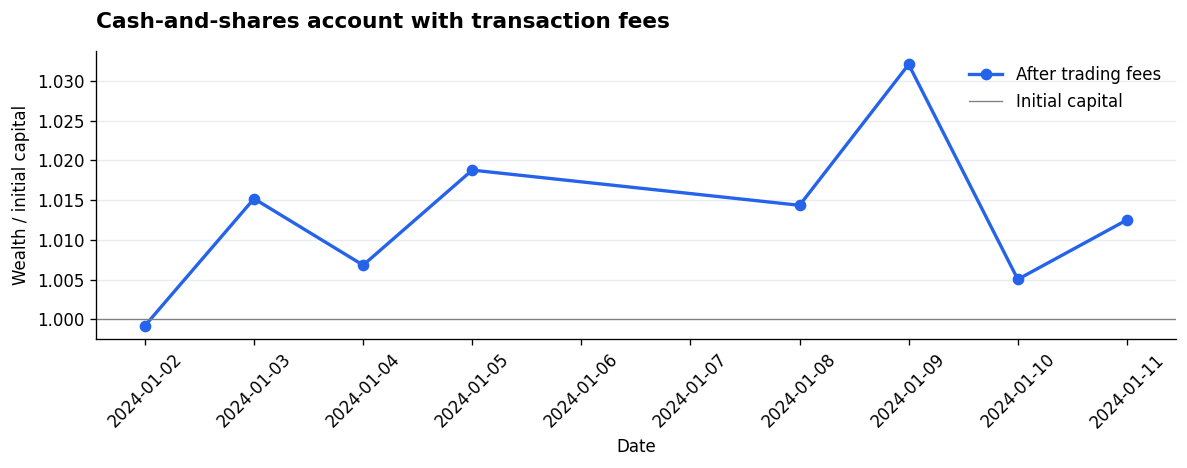

In [16]:
plt.figure(figsize=(10, 4))
plt.plot(result["date"], result["nav"], color=BLUE, marker="o", label="After trading fees")
plt.axhline(1, color="grey", linewidth=0.8, label="Initial capital")
plt.title("Cash-and-shares account with transaction fees")
plt.xlabel("Date")
plt.ylabel("Wealth / initial capital")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**怎么看：** 看前两行：目标权重同为0.8，但价格上涨后原股票占比变大，仍需卖出一小部分，因此有真实费用。首行净值略低于1是首次建仓费；末行费用包含全部平仓。

**换数据时注意：** 此模板限单资产、只做多、现金收益0、小数股、每次收盘再平衡；手续费按买卖成交绝对金额计，不除以2。turnover=当次成交名义金额/交易前权益；不是target_weight.diff()。本例不处理冲击成本、最低手续费、整数股、税费或拆股分红现金流；若close是原始价格，需另记这些企业行动。

<a id='B06'></a>
## B06 · 多资产宽表：先合并每日持仓收益，再复合组合净值

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [17]:
df = pd.DataFrame({
    "date": pd.bdate_range("2024-01-02", periods=8),
    "price_A": [100, 102, 101, 104, 103, 105, 102, 104],
    "price_B": [50, 49, 50, 51, 50, 49, 50, 51],
    "weight_A": [0.6, 0.6, 0.5, 0.5, 0.0, 0.5, 0.0, 0.0],
    "weight_B": [0.4, 0.4, -0.5, -0.5, 0.0, -0.5, 0.0, 0.0],
})
display(df)

,date,price_A,price_B,weight_A,weight_B
0,2024-01-02,100,50,0.6,0.4
1,2024-01-03,102,49,0.6,0.4
2,2024-01-04,101,50,0.5,-0.5
3,2024-01-05,104,51,0.5,-0.5
4,2024-01-08,103,50,0.0,0.0
5,2024-01-09,105,49,0.5,-0.5
6,2024-01-10,102,50,0.0,0.0
7,2024-01-11,104,51,0.0,0.0


**场景 / 要做什么：**

每个日期一行，price_A/B为两资产同一收盘时点的价格；weight_A/B为该收盘成交前已知的组合资金目标权重。0.6/0.4表示60%/40%多头；0.5/-0.5表示50%做多A、50%做空B。每天再平衡，以前一天权重乘当天各资产收益，并逐行求和得到组合收益；最后只对组合收益做cumprod。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [18]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and df["date"].is_unique
assert np.isfinite(df[["price_A", "price_B", "weight_A", "weight_B"]].to_numpy()).all()
assert (df[["price_A", "price_B"]] > 0).all().all()
assert (df[["weight_A", "weight_B"]].abs().sum(axis=1) <= 1 + 1e-12).all()

returns = df[["price_A", "price_B"]].pct_change(fill_method=None)
returns.columns = ["A", "B"]
weights = df[["weight_A", "weight_B"]].copy()
weights.columns = ["A", "B"]  # 标签对齐后相乘，避免列名不同产生NaN。
held = weights.shift(1, fill_value=0)
contribution = held * returns
contribution.iloc[0] = 0.0  # 首行之前明确没有持仓。
df["contribution_A"] = contribution["A"]
df["contribution_B"] = contribution["B"]
df["strategy_ret"] = contribution.sum(axis=1, min_count=2)
assert df["strategy_ret"].notna().all() and (1 + df["strategy_ret"] > 0).all()
df["gross_exposure"] = held.abs().sum(axis=1)
df["net_exposure"] = held.sum(axis=1)
df["nav"] = (1 + df["strategy_ret"]).cumprod()
display(df[["date", "weight_A", "weight_B", "contribution_A", "contribution_B", "strategy_ret", "gross_exposure", "net_exposure", "nav"]].round(4))

,date,weight_A,weight_B,contribution_A,contribution_B,strategy_ret,gross_exposure,net_exposure,nav
0,2024-01-02,0.6,0.4,0.0000,0.0000,0.0000,0.0,0.0,1.0000
1,2024-01-03,0.6,0.4,0.0120,-0.0080,0.0040,1.0,1.0,1.0040
2,2024-01-04,0.5,-0.5,-0.0059,0.0082,0.0023,1.0,1.0,1.0063
3,2024-01-05,0.5,-0.5,0.0149,-0.0100,0.0049,1.0,0.0,1.0112
4,2024-01-08,0.0,0.0,-0.0048,0.0098,0.0050,1.0,0.0,1.0162
5,2024-01-09,0.5,-0.5,0.0000,-0.0000,0.0000,0.0,0.0,1.0162
6,2024-01-10,0.0,0.0,-0.0143,-0.0102,-0.0245,1.0,0.0,0.9913
7,2024-01-11,0.0,0.0,0.0000,0.0000,0.0000,0.0,0.0,0.9913


**可视化：** 直接使用刚刚算出的结果。

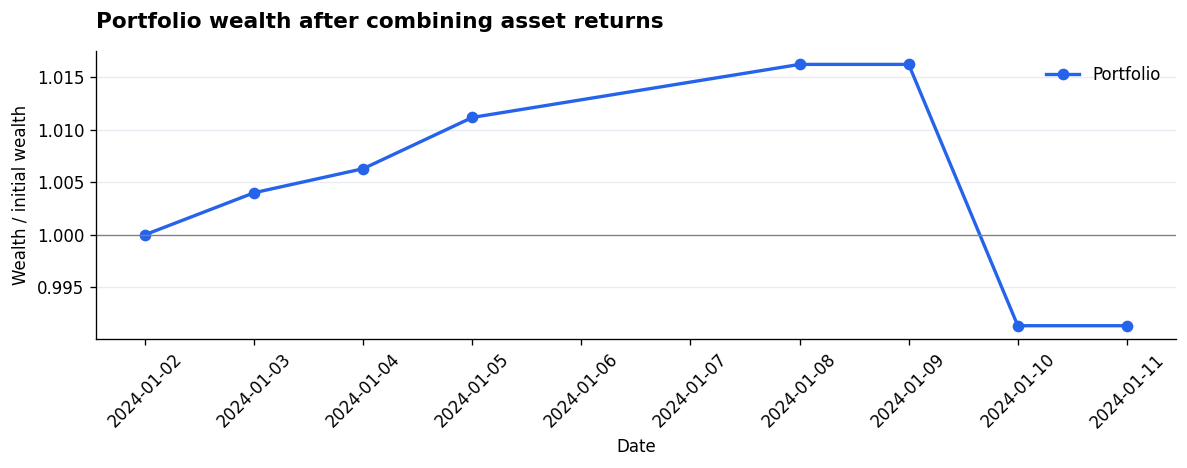

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(df["date"], df["nav"], color=BLUE, marker="o", label="Portfolio")
plt.axhline(1, color="grey", linewidth=0.8)
plt.title("Portfolio wealth after combining asset returns")
plt.xlabel("Date")
plt.ylabel("Wealth / initial wealth")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**怎么看：** 结果中contribution_A和contribution_B相加恰好是strategy_ret。50%多A、50%空B时net_exposure为0，但gross_exposure为1，仍然承担价格风险；空仓区间净值不变。

**换数据时注意：** 假定日频再平衡、收益价格口径一致且包含相应分红拆股调整，现金利息与融资成本为0，忽略费用及借券约束。首行没有历史持仓；表中gross/net为刚结束区间的持仓敞口。不能先把各资产独立复合，再相加当作动态再平衡组合；缺失资产收益也不能默认当0。

<a id='B07'></a>
## B07 · 多资产长表：上一期权重 × 当期资产收益

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [20]:
df = pd.DataFrame({
    "date": np.repeat(pd.bdate_range("2025-01-06", periods=6), 2),
    "asset": ["A", "B"] * 6,
    "price": [100, 50, 102, 49, 101, 50, 104, 51, 103, 52, 105, 51],
    "weight": [0.6, 0.4, 0.6, 0.4, 0.3, 0.7, 0.3, 0.7, 0.5, 0.5, 0.5, 0.5],
})
display(df)

,date,asset,price,weight
0,2025-01-06,A,100,0.6
1,2025-01-06,B,50,0.4
2,2025-01-07,A,102,0.6
3,2025-01-07,B,49,0.4
4,2025-01-08,A,101,0.3
5,2025-01-08,B,50,0.7
6,2025-01-09,A,104,0.3
7,2025-01-09,B,51,0.7
8,2025-01-10,A,103,0.5
9,2025-01-10,B,52,0.5


**场景 / 要做什么：**

输入是 date / asset / price / weight 长表，每个日期必须有所有资产的有效价格和目标权重。weight 是交易前已知、在该日收盘成交后的目标权重，只赚下一行的收盘到收盘收益。任务：先核对共同日历，再计算逐资产贡献和组合净值。本例每日再平衡、允许零权重现金、不收费用；首行没有历史持仓收益。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [21]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["date", "asset"]).reset_index(drop=True)
assert df[["date", "asset"]].notna().all().all(), "日期/资产不能为空"
assert not df.duplicated(["date", "asset"]).any(), "同一日期/资产不能有重复记录"

# pivot 会把某日缺少的资产变成 NaN：先拒绝，不能把缺报价当作 0 收益。
prices = df.pivot(index="date", columns="asset", values="price")
targets = df.pivot(index="date", columns="asset", values="weight").reindex_like(prices)
assert np.isfinite(prices.to_numpy()).all() and prices.gt(0).all().all(), "先处理缺价/无效价格"
assert np.isfinite(targets.to_numpy()).all(), "每个日期/资产都要有明确目标权重"
assert targets.ge(0).all().all() and targets.sum(axis=1).le(1 + 1e-10).all()

asset_return = prices.pct_change(fill_method=None)
held_weight = targets.shift(1, fill_value=0)  # 上日收盘后持仓，赚当日区间收益
contribution = held_weight * asset_return
contribution.iloc[0] = 0  # 只处理首行：没有此前持仓，不是填补中途缺价
portfolio_return = contribution.sum(axis=1, skipna=False)
nav = (1 + portfolio_return).cumprod()

# asset_return 首行保留 NaN，清楚表示“没有前一日价格”。
result = df.set_index(["date", "asset"])[["price", "weight"]].copy()
result["held_weight"] = held_weight.stack()
result["asset_return"] = asset_return.stack()  # 按索引对齐后，首行仍为 NaN
result["contribution"] = contribution.stack()
display(result.reset_index().round(4))
daily = pd.DataFrame({"portfolio_return": portfolio_return, "nav": nav})
display(daily.round(4))

,date,asset,price,weight,held_weight,asset_return,contribution
0,2025-01-06,A,100,0.6,0.0,NaN,0.0000
1,2025-01-06,B,50,0.4,0.0,NaN,0.0000
2,2025-01-07,A,102,0.6,0.6,0.0200,0.0120
3,2025-01-07,B,49,0.4,0.4,-0.0200,-0.0080
4,2025-01-08,A,101,0.3,0.6,-0.0098,-0.0059
5,2025-01-08,B,50,0.7,0.4,0.0204,0.0082
6,2025-01-09,A,104,0.3,0.3,0.0297,0.0089
7,2025-01-09,B,51,0.7,0.7,0.0200,0.0140
8,2025-01-10,A,103,0.5,0.3,-0.0096,-0.0029
9,2025-01-10,B,52,0.5,0.7,0.0196,0.0137


,portfolio_return,nav
date,,
2025-01-06,0.0000,1.0000
2025-01-07,0.0040,1.0040
2025-01-08,0.0023,1.0063
2025-01-09,0.0229,1.0293
2025-01-10,0.0108,1.0405
2025-01-13,0.0001,1.0406


**可视化：** 直接使用刚刚算出的结果。

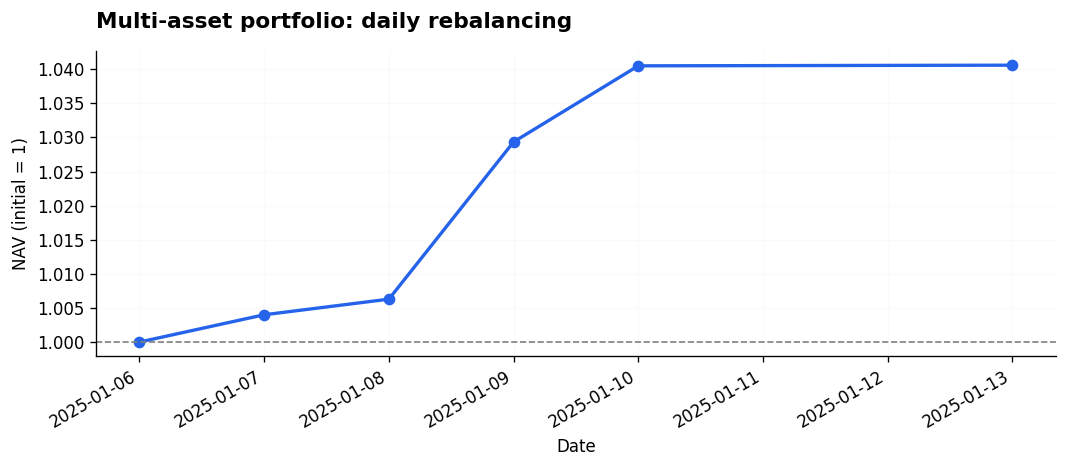

In [22]:
plt.figure(figsize=(9, 4))
plt.plot(daily.index, daily["nav"], color=BLUE, marker="o", linewidth=2)
plt.axhline(1, color="grey", linestyle="--", linewidth=1)
plt.title("Multi-asset portfolio: daily rebalancing")
plt.xlabel("Date")
plt.ylabel("NAV (initial = 1)")
plt.xticks(rotation=30, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**怎么看：** 先看长表中的 held_weight：必须是同一资产上一日的目标权重。每天 contribution 加总后得到组合收益，再复合成 NAV；资产不能串行 shift，否则 A 会错用 B 的记录。

**换数据时注意：** 本例的目标权重每天重置，所以不是买入后持有。没有手续费、利息和滑点；若加交易费，换手必须与价格变化后的真实权重比较。完整共同日历仅按输入中的日期检查：若所有资产同时缺掉一个应交易日，仍须用交易所日历另行检查。

<a id='B08'></a>
## B08 · 每周再平衡：固定股数持有，权重自然漂移

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [23]:
df = pd.DataFrame({
    "date": pd.bdate_range("2025-01-06", periods=10),
    "price_a": [100, 103, 101, 105, 107, 106, 108, 104, 109, 111],
    "price_b": [50, 49, 50, 49, 48, 49, 47, 50, 49, 48],
    "rebal": [True, False, False, False, False, True, False, False, False, False],
    "target_a": [0.6] * 10,
    "target_b": [0.4] * 10,
})
display(df)

,date,price_a,price_b,rebal,target_a,target_b
0,2025-01-06,100,50,True,0.6,0.4
1,2025-01-07,103,49,False,0.6,0.4
2,2025-01-08,101,50,False,0.6,0.4
3,2025-01-09,105,49,False,0.6,0.4
4,2025-01-10,107,48,False,0.6,0.4
5,2025-01-13,106,49,True,0.6,0.4
6,2025-01-14,108,47,False,0.6,0.4
7,2025-01-15,104,50,False,0.6,0.4
8,2025-01-16,109,49,False,0.6,0.4
9,2025-01-17,111,48,False,0.6,0.4


**场景 / 要做什么：**

输入包含两只资产价格、再平衡标记 rebal 和目标权重。任务：仅在 rebal=True 的收盘按目标权重交易，其余日期固定股数、按价格估值，展示实际权重漂移和账户净值。目标权重须在成交前已知；初始资金 10,000，允许碎股，现金无利息，本例费用为 0。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [24]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and not df["date"].duplicated().any()
assert df["rebal"].isin([True, False]).all()
assert np.isfinite(df[["price_a", "price_b"]].to_numpy()).all()
assert df[["price_a", "price_b"]].gt(0).all().all()
assert np.isfinite(df[["target_a", "target_b"]].to_numpy()).all()
assert df[["target_a", "target_b"]].ge(0).all().all()
assert df[["target_a", "target_b"]].sum(axis=1).le(1 + 1e-10).all()

initial_cash = 10000.0
cash, shares_a, shares_b = initial_cash, 0.0, 0.0
history = []
for row in df.itertuples(index=False):
    equity = cash + shares_a * row.price_a + shares_b * row.price_b
    if row.rebal:
        # 先按当前价格估值，再重新配置股数。无费用，所以交易不改变权益。
        shares_a = equity * row.target_a / row.price_a
        shares_b = equity * row.target_b / row.price_b
        cash = equity - shares_a * row.price_a - shares_b * row.price_b
    history.append({"date": row.date, "rebal": row.rebal,
                    "shares_a": shares_a, "shares_b": shares_b,
                    "weight_a": shares_a * row.price_a / equity,
                    "weight_b": shares_b * row.price_b / equity,
                    "cash": cash, "equity": equity, "nav": equity / initial_cash})

result = pd.DataFrame(history)
display(result.round(4))

,date,rebal,shares_a,shares_b,weight_a,weight_b,cash,equity,nav
0,2025-01-06,True,60.0000,80.0000,0.6000,0.4000,0.0,10000.0000,1.0000
1,2025-01-07,False,60.0000,80.0000,0.6119,0.3881,0.0,10100.0000,1.0100
2,2025-01-08,False,60.0000,80.0000,0.6024,0.3976,0.0,10060.0000,1.0060
3,2025-01-09,False,60.0000,80.0000,0.6164,0.3836,0.0,10220.0000,1.0220
4,2025-01-10,False,60.0000,80.0000,0.6257,0.3743,0.0,10260.0000,1.0260
5,2025-01-13,True,58.1887,83.9184,0.6000,0.4000,0.0,10280.0000,1.0280
6,2025-01-14,False,58.1887,83.9184,0.6144,0.3856,0.0,10228.5406,1.0229
7,2025-01-15,False,58.1887,83.9184,0.5905,0.4095,0.0,10247.5410,1.0248
8,2025-01-16,False,58.1887,83.9184,0.6067,0.3933,0.0,10454.5660,1.0455
9,2025-01-17,False,58.1887,83.9184,0.6159,0.3841,0.0,10487.0250,1.0487


**可视化：** 直接使用刚刚算出的结果。

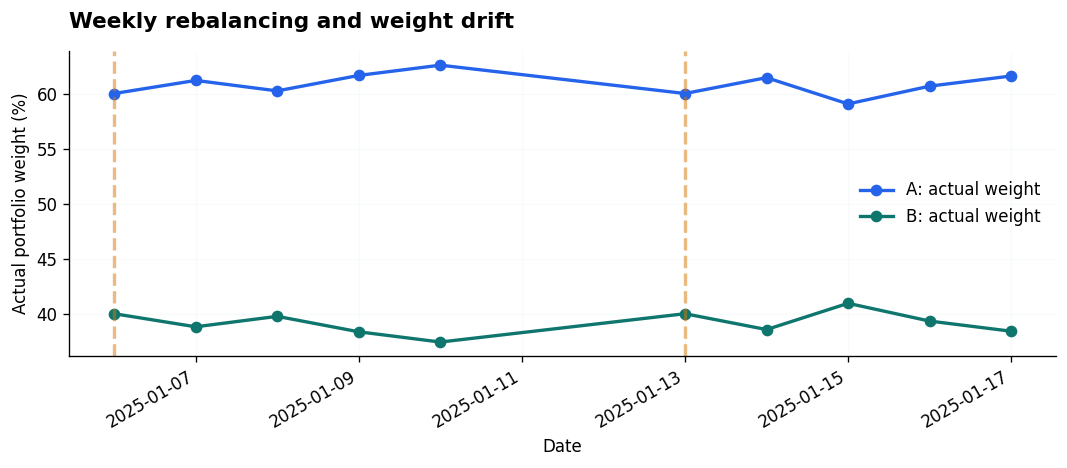

In [25]:
plt.figure(figsize=(9, 4))
plt.plot(result["date"], result["weight_a"] * 100, color=BLUE, marker="o", label="A: actual weight")
plt.plot(result["date"], result["weight_b"] * 100, color=TEAL, marker="o", label="B: actual weight")
# 虚线标记真正调仓日，其余日期的权重会随价格变化。
for day in result.loc[result["rebal"], "date"]:
    plt.axvline(day, color=ORANGE, linestyle="--", alpha=0.5)
plt.title("Weekly rebalancing and weight drift")
plt.xlabel("Date")
plt.ylabel("Actual portfolio weight (%)")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**怎么看：** 橙色虚线当天收盘后，权重回到 60% / 40%。两次调仓之间 shares_a 和 shares_b 不变，但实际权重变化，这就是持仓漂移。收益表现可直接查看表中的 equity 或 nav。

**换数据时注意：** 把周目标权重 ffill 到每天后再乘日收益，会实现每日恢复目标权重的另一种策略。需要真实费用时，应按新旧股数差乘成交价计费，并调整现金或可买数量；不能直接沿用本例的无费全额配置。

<a id='B09'></a>
## B09 · 每天固定金额开平仓：累计金额损益，不复合交易收益

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [26]:
df = pd.DataFrame({
    "date": pd.bdate_range("2025-01-06", periods=10),
    "open": [100, 102, 101, 103, 104, 103, 105, 104, 106, 107],
    "close": [102, 101, 103, 104, 103, 105, 104, 106, 107, 106],
    "amount": [1000.0] * 10,
})
display(df)

,date,open,close,amount
0,2025-01-06,100,102,1000.0
1,2025-01-07,102,101,1000.0
2,2025-01-08,101,103,1000.0
3,2025-01-09,103,104,1000.0
4,2025-01-10,104,103,1000.0
5,2025-01-13,103,105,1000.0
6,2025-01-14,105,104,1000.0
7,2025-01-15,104,106,1000.0
8,2025-01-16,106,107,1000.0
9,2025-01-17,107,106,1000.0


**场景 / 要做什么：**

每天用固定 1,000 元按 open 买入，并在当天 close 全部卖出；amount 不随盈利增长。任务：计算每日金额损益和初始 3,000 元账户的资金曲线，与简单固定投入示例对应。策略在开盘前已确定，允许碎股，忽略费用；每天收盘之后全部为现金。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [27]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and not df["date"].duplicated().any()
assert np.isfinite(df[["open", "close", "amount"]].to_numpy()).all()
assert df[["open", "close", "amount"]].gt(0).all().all()
assert df["amount"].nunique() == 1, "这个模板专门用于每日固定金额"

initial_cash = 3000.0
result = df.copy()
result["trade_return"] = result["close"] / result["open"] - 1
result["pnl"] = result["amount"] * result["trade_return"]
result["cash_before"] = initial_cash + result["pnl"].cumsum().shift(1, fill_value=0)
if (result["cash_before"] < result["amount"] - 1e-10).any():
    raise ValueError("某天开盘前现金不足，不能继续按固定金额买入")
result["equity"] = initial_cash + result["pnl"].cumsum()
# 账户收益率的分母是当日开盘前账户权益，不能误用 1,000 元交易本金。
result["account_return"] = result["pnl"] / result["cash_before"]
result["nav"] = result["equity"] / initial_cash
display(result.round(4))

,date,open,close,amount,trade_return,pnl,cash_before,equity,account_return,nav
0,2025-01-06,100,102,1000.0,0.0200,20.0000,3000.0000,3020.0000,0.0067,1.0067
1,2025-01-07,102,101,1000.0,-0.0098,-9.8039,3020.0000,3010.1961,-0.0032,1.0034
2,2025-01-08,101,103,1000.0,0.0198,19.8020,3010.1961,3029.9981,0.0066,1.0100
3,2025-01-09,103,104,1000.0,0.0097,9.7087,3029.9981,3039.7068,0.0032,1.0132
4,2025-01-10,104,103,1000.0,-0.0096,-9.6154,3039.7068,3030.0914,-0.0032,1.0100
5,2025-01-13,103,105,1000.0,0.0194,19.4175,3030.0914,3049.5089,0.0064,1.0165
6,2025-01-14,105,104,1000.0,-0.0095,-9.5238,3049.5089,3039.9851,-0.0031,1.0133
7,2025-01-15,104,106,1000.0,0.0192,19.2308,3039.9851,3059.2158,0.0063,1.0197
8,2025-01-16,106,107,1000.0,0.0094,9.4340,3059.2158,3068.6498,0.0031,1.0229
9,2025-01-17,107,106,1000.0,-0.0093,-9.3458,3068.6498,3059.3040,-0.0030,1.0198


**可视化：** 直接使用刚刚算出的结果。

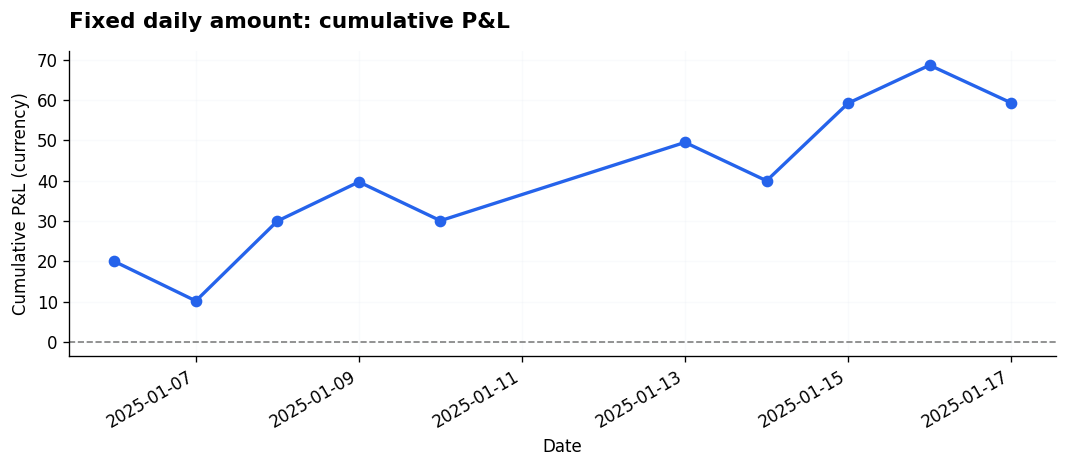

In [28]:
plt.figure(figsize=(9, 4))
plt.plot(result["date"], result["equity"] - initial_cash,
         color=BLUE, marker="o", linewidth=2)
plt.axhline(0, color="grey", linestyle="--", linewidth=1)
plt.title("Fixed daily amount: cumulative P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (currency)")
plt.xticks(rotation=30, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**怎么看：** 这条线是 pnl.cumsum()，每天投入仍是 1,000 元。trade_return 描述当天这笔交易；account_return 描述整个 3,000 元起始账户，两者分母不同。

**换数据时注意：** 不能对 trade_return 直接 cumprod 后宣称是该固定金额账户的净值。当天开盘后才能观测到的信息不能反过来决定当天开盘成交；若信号来自开盘价本身，需要换成更晚的可成交价格。本例没有隔夜持仓、交易费用和融资。

<a id='B10'></a>
## B10 · 买入 / 持有 / 卖出指令：现金与股数账本

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [29]:
df = pd.DataFrame({
    "date": pd.bdate_range("2025-01-06", periods=10),
    "price": [100, 102, 101, 104, 103, 105, 103, 107, 108, 106],
    "order": ["buy", "hold", "buy", "sell", "hold", "buy", "buy", "hold", "sell", "buy"],
})
display(df)

,date,price,order
0,2025-01-06,100,buy
1,2025-01-07,102,hold
2,2025-01-08,101,buy
3,2025-01-09,104,sell
4,2025-01-10,103,hold
5,2025-01-13,105,buy
6,2025-01-14,103,buy
7,2025-01-15,107,hold
8,2025-01-16,108,sell
9,2025-01-17,106,buy


**场景 / 要做什么：**

order 是成交前已经可执行的外部指令，price 是对应成交及估值价格。任务：buy 每次买入 1,000 元名义金额，重复 buy 继续加仓；sell 清空全部股数；hold 不交易。初始现金 5,000 元，买卖每边费率 10 bps，按成交金额扣费，允许碎股。输出现金、股数、手续费和账户权益。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [30]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and not df["date"].duplicated().any()
assert np.isfinite(df["price"].to_numpy()).all() and df["price"].gt(0).all()
assert df["order"].isin(["buy", "hold", "sell"]).all()

initial_cash, ticket, fee_rate = 5000.0, 1000.0, 10 / 10000
cash, shares, previous_equity = initial_cash, 0.0, initial_cash
history = []
for row in df.itertuples(index=False):
    fee, trade_notional = 0.0, 0.0
    if row.order == "buy":
        fee = ticket * fee_rate
        if cash < ticket + fee - 1e-10:
            raise ValueError("现金不足以支付买入金额和手续费")
        shares += ticket / row.price  # 再次 buy 会累加股数
        cash -= ticket + fee
        trade_notional = ticket
    elif row.order == "sell":
        trade_notional = -shares * row.price
        fee = abs(trade_notional) * fee_rate
        cash += shares * row.price - fee
        shares = 0.0
    equity = cash + shares * row.price  # 未卖出的持仓也按市场价格计入权益
    history.append({"date": row.date, "order": row.order, "price": row.price,
                    "trade_notional": trade_notional, "fee": fee,
                    "cash": cash, "shares": shares, "equity": equity,
                    "account_return": equity / previous_equity - 1})
    previous_equity = equity

result = pd.DataFrame(history)
display(result.round(4))

,date,order,price,trade_notional,fee,cash,shares,equity,account_return
0,2025-01-06,buy,100,1000.0000,1.0000,3999.0000,10.0000,4999.0000,-0.0002
1,2025-01-07,hold,102,0.0000,0.0000,3999.0000,10.0000,5019.0000,0.0040
2,2025-01-08,buy,101,1000.0000,1.0000,2998.0000,19.9010,5008.0000,-0.0022
3,2025-01-09,sell,104,-2069.7030,2.0697,5065.6333,0.0000,5065.6333,0.0115
4,2025-01-10,hold,103,0.0000,0.0000,5065.6333,0.0000,5065.6333,0.0000
5,2025-01-13,buy,105,1000.0000,1.0000,4064.6333,9.5238,5064.6333,-0.0002
6,2025-01-14,buy,103,1000.0000,1.0000,3063.6333,19.2325,5044.5856,-0.0040
7,2025-01-15,hold,107,0.0000,0.0000,3063.6333,19.2325,5121.5158,0.0153
8,2025-01-16,sell,108,-2077.1151,2.0771,5138.6713,0.0000,5138.6713,0.0033
9,2025-01-17,buy,106,1000.0000,1.0000,4137.6713,9.4340,5137.6713,-0.0002


**可视化：** 直接使用刚刚算出的结果。

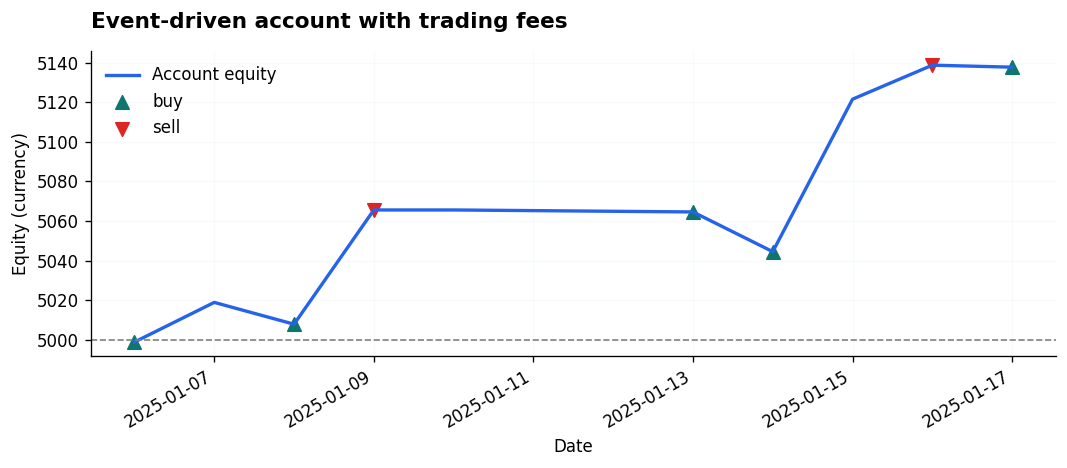

In [31]:
plt.figure(figsize=(9, 4))
plt.plot(result["date"], result["equity"], color=BLUE, linewidth=2, label="Account equity")
for order, marker, color in [("buy", "^", TEAL), ("sell", "v", RED)]:
    traded = result["order"].eq(order) & result["trade_notional"].ne(0)
    plt.scatter(result.loc[traded, "date"], result.loc[traded, "equity"],
                marker=marker, color=color, s=65, label=order)
plt.axhline(initial_cash, color="grey", linestyle="--", linewidth=1)
plt.title("Event-driven account with trading fees")
plt.xlabel("Date")
plt.ylabel("Equity (currency)")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**怎么看：** 绿色三角表示加仓，红色三角表示清仓。第一笔买入就支付手续费，因此首日权益是 4,999 而不是 5,000；account_return 已包含这一笔成本。

**换数据时注意：** 最后一天不自动清仓：未平仓部分按市价估值，未来卖出费用尚未计入。持有期间股数固定，因此可复用到更复杂的指令系统。若 order 从当日收盘数据生成，不能假装仍可在同一收盘价成交；应改用下一次真实可交易的价格。

<a id='B11'></a>
## B11 · 双腿配对交易：分别计算两条腿的收益贡献

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [32]:
df = pd.DataFrame({
    "date": pd.bdate_range("2025-01-06", periods=10),
    "price_a": [100, 102, 101, 103, 102, 104, 106, 105, 107, 108],
    "price_b": [50, 50.5, 51, 51.5, 51, 52.5, 52, 53, 53.5, 54],
    "side": [1, 1, 0, -1, -1, 0, 1, 1, -1, 0],
})
display(df)

,date,price_a,price_b,side
0,2025-01-06,100,50.0,1
1,2025-01-07,102,50.5,1
2,2025-01-08,101,51.0,0
3,2025-01-09,103,51.5,-1
4,2025-01-10,102,51.0,-1
5,2025-01-13,104,52.5,0
6,2025-01-14,106,52.0,1
7,2025-01-15,105,53.0,1
8,2025-01-16,107,53.5,-1
9,2025-01-17,108,54.0,0


**场景 / 要做什么：**

side=1 表示多 A / 空 B，side=-1 表示空 A / 多 B，side=0 空仓；非零时每条腿的绝对权重均为 0.5，总绝对敞口为账户权益的 100%。side 在该行收盘成交前已知，持仓赚下一行区间收益。任务：用真实两条腿收益算组合收益和逐腿累计金额损益，不能把价差当作可投资价格。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [33]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and not df["date"].duplicated().any()
assert np.isfinite(df[["price_a", "price_b"]].to_numpy()).all()
assert df[["price_a", "price_b"]].gt(0).all().all()
assert df["side"].isin([-1, 0, 1]).all()

initial_cash = 10000.0
returns = df[["price_a", "price_b"]].pct_change(fill_method=None)
returns.iloc[0] = 0  # 首行没有此前持仓；中途缺价格已在上方拒绝
held_side = df["side"].shift(1, fill_value=0)
contribution_a = 0.5 * held_side * returns["price_a"]
contribution_b = -0.5 * held_side * returns["price_b"]
portfolio_return = contribution_a + contribution_b
assert portfolio_return.gt(-1).all(), "权益耗尽，需另写破产/保证金规则"
equity = initial_cash * (1 + portfolio_return).cumprod()
equity_before = equity.shift(1, fill_value=initial_cash)

result = df[["date", "side"]].copy()
result["held_side"] = held_side
result["pnl_a"] = equity_before * contribution_a
result["pnl_b"] = equity_before * contribution_b
result["portfolio_return"] = portfolio_return
result["equity"] = equity
display(result.round(4))

,date,side,held_side,pnl_a,pnl_b,portfolio_return,equity
0,2025-01-06,1,0,0.0000,-0.0000,0.0000,10000.0000
1,2025-01-07,1,1,100.0000,-50.0000,0.0050,10050.0000
2,2025-01-08,0,1,-49.2647,-49.7525,-0.0099,9950.9828
3,2025-01-09,-1,0,0.0000,-0.0000,0.0000,9950.9828
4,2025-01-10,-1,-1,48.3057,-48.3057,0.0000,9950.9828
5,2025-01-13,0,-1,-97.5587,146.3380,0.0049,9999.7621
6,2025-01-14,1,0,0.0000,0.0000,0.0000,9999.7621
7,2025-01-15,1,1,-47.1687,-96.1516,-0.0143,9856.4419
8,2025-01-16,-1,1,93.8709,-46.4927,0.0048,9903.8201
9,2025-01-17,0,-1,-46.2795,46.2795,0.0000,9903.8201


**可视化：** 直接使用刚刚算出的结果。

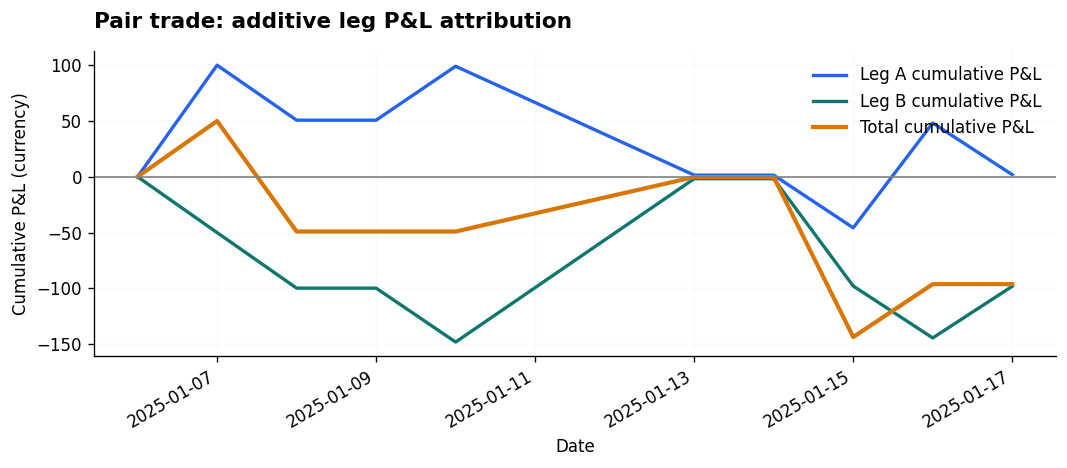

In [34]:
plt.figure(figsize=(9, 4))
plt.plot(result["date"], result["pnl_a"].cumsum(), color=BLUE, label="Leg A cumulative P&L")
plt.plot(result["date"], result["pnl_b"].cumsum(), color=TEAL, label="Leg B cumulative P&L")
plt.plot(result["date"], result["equity"] - initial_cash,
         color=ORANGE, linewidth=2.5, label="Total cumulative P&L")
plt.axhline(0, color="grey", linewidth=1)
plt.title("Pair trade: additive leg P&L attribution")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (currency)")
plt.legend()
plt.xticks(rotation=30, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**怎么看：** 蓝线与绿线逐点相加必须等于橙线。先用同一份期初账户权益把逐腿收益贡献转成金额损益，然后分别 cumsum；不能把两条腿各自 cumprod 后再加总。

**换数据时注意：** 本例每日按当前权益重置双腿权重，忽略交易费、借券费、融资和保证金限制，不是固定股数的价差仓位。price_a - price_b 可能过零，spread.pct_change() 既可能爆炸，也没有定义清楚投入资本；不能代替两条腿 P&L。若 side 来自当天收盘价，应延后至下一可交易时点执行。

<a id='B12'></a>
## B12 · 每次持有三期：三个错峰子账户处理重叠交易

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [35]:
df = pd.DataFrame({
    "date": pd.bdate_range("2025-01-06", periods=12),
    "price": [100, 102, 101, 104, 103, 105, 107, 106, 108, 105, 109, 110],
    "signal": [1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1],
})
display(df)

,date,price,signal
0,2025-01-06,100,1
1,2025-01-07,102,1
2,2025-01-08,101,0
3,2025-01-09,104,1
4,2025-01-10,103,0
5,2025-01-13,105,1
6,2025-01-14,107,1
7,2025-01-15,106,1
8,2025-01-16,108,0
9,2025-01-17,105,1


**场景 / 要做什么：**

每天产生一个交易前已知的 0/1 信号，每笔多头从该日收盘持有到第三个后续观测的收盘。任务：初始 3,000 元平均分到三个错峰子账户，每天轮到一个子账户先结束旧持仓，再按信号开新仓；其余子账户固定股数持有。允许碎股、无手续费，未开仓资金留现金。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [36]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
assert df["date"].notna().all() and not df["date"].duplicated().any()
assert np.isfinite(df["price"].to_numpy()).all() and df["price"].gt(0).all()
assert df["signal"].isin([0, 1]).all()

initial_cash, holding_bars = 3000.0, 3
sleeve_cash = np.full(holding_bars, initial_cash / holding_bars)
sleeve_shares = np.zeros(holding_bars)
history = []
previous_equity = initial_cash
for t, row in enumerate(df.itertuples(index=False)):
    k = t % holding_bars  # 0,1,2,0,1,2...：每个子账户隔三期轮到一次
    # 仅轮到的子账户到期；其他子账户的股数保持不变。
    sleeve_cash[k] += sleeve_shares[k] * row.price
    sleeve_shares[k] = 0.0
    if row.signal == 1:
        sleeve_shares[k] = sleeve_cash[k] / row.price
        sleeve_cash[k] = 0.0
    values = sleeve_cash + sleeve_shares * row.price
    equity = values.sum()
    history.append({"date": row.date, "price": row.price, "signal": row.signal,
                    "rotating_sleeve": k + 1,
                    "value_1": values[0], "value_2": values[1], "value_3": values[2],
                    "cash": sleeve_cash.sum(), "equity": equity,
                    "account_return": equity / previous_equity - 1})
    previous_equity = equity

result = pd.DataFrame(history)
display(result.round(4))

,date,price,signal,rotating_sleeve,value_1,value_2,value_3,cash,equity,account_return
0,2025-01-06,100,1,1,1000.0,1000.0000,1000.0000,2000.0000,3000.0000,0.0000
1,2025-01-07,102,1,2,1020.0,1000.0000,1000.0000,1000.0000,3020.0000,0.0067
2,2025-01-08,101,0,3,1010.0,990.1961,1000.0000,1000.0000,3000.1961,-0.0066
3,2025-01-09,104,1,1,1040.0,1019.6078,1000.0000,1000.0000,3059.6078,0.0198
4,2025-01-10,103,0,2,1030.0,1009.8039,1000.0000,2009.8039,3039.8039,-0.0065
5,2025-01-13,105,1,3,1050.0,1009.8039,1000.0000,1009.8039,3059.8039,0.0066
6,2025-01-14,107,1,1,1070.0,1009.8039,1019.0476,1009.8039,3098.8515,0.0128
7,2025-01-15,106,1,2,1060.0,1009.8039,1009.5238,0.0000,3079.3277,-0.0063
8,2025-01-16,108,0,3,1080.0,1028.8568,1028.5714,1028.5714,3137.4283,0.0189
9,2025-01-17,105,1,1,1050.0,1000.2775,1028.5714,1028.5714,3078.8489,-0.0187


**可视化：** 直接使用刚刚算出的结果。

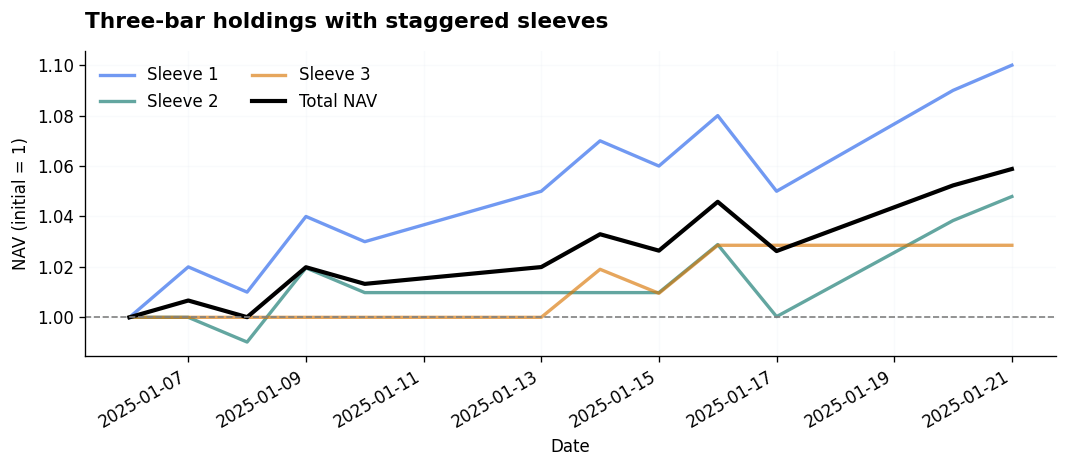

In [37]:
plt.figure(figsize=(9, 4))
for column, label, color in [("value_1", "Sleeve 1", BLUE),
                              ("value_2", "Sleeve 2", TEAL),
                              ("value_3", "Sleeve 3", ORANGE)]:
    plt.plot(result["date"], result[column] / (initial_cash / holding_bars),
             color=color, alpha=0.65, label=label)
plt.plot(result["date"], result["equity"] / initial_cash,
         color="black", linewidth=2.5, label="Total NAV")
plt.axhline(1, color="grey", linestyle="--", linewidth=1)
plt.title("Three-bar holdings with staggered sleeves")
plt.xlabel("Date")
plt.ylabel("NAV (initial = 1)")
plt.legend(ncol=2)
plt.xticks(rotation=30, ha="right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**怎么看：** 子账户 1 在第 0、3、6、9 行轮换；子账户 2、3 错开一行、两行。同一天可能有三笔重叠持仓，但每笔用不同的资金。总 NAV 是三个子账户 NAV 的平均，因为初始资本均等。

**换数据时注意：** 三个子账户仅在起点各占总资本 1/3，之后各自盈利再投入，其占比会漂移，不能宣称每天维持 1/3。每笔持有三个观测区间，不一定是三个自然日。末端尚未到期的交易只按市价估值，不强行平仓；实际缺失交易日需先补齐/定义交易日历。多日 forward return 是评估标签，不能逐日 cumprod 当作可执行账户收益。

<a id='B13'></a>
## B13 · 波动率目标仓位：只使用交易前已经知道的风险

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [38]:
df = pd.DataFrame({
    'open':  [100, 101, 99, 102, 101, 104, 103, 106, 104, 102, 105, 107],
    'close': [101, 99, 102, 101, 104, 103, 106, 104, 102, 105, 107, 106],
}, index=pd.bdate_range('2024-01-08', periods=12))
display(df)

,open,close
2024-01-08,100,101
2024-01-09,101,99
2024-01-10,99,102
2024-01-11,102,101
2024-01-12,101,104
2024-01-15,104,103
2024-01-16,103,106
2024-01-17,106,104
2024-01-18,104,102
2024-01-19,102,105


**场景 / 要做什么：**

**场景：** 希望波动大时少持仓、波动小时多持仓。输入为日频 `open / close`，每行代表一场交易会话。

**要做什么：** 用截至 t 日收盘的历史收益估计波动，决定 t+1 日开盘的仓位；持有至下一开盘。表中的 `asset_return[t]` 结束于 t 日开盘，所以乘的是 t−2 日收盘计算的权重。例中窗口 3 天便于手算，真实研究可事先选择更长窗口。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [39]:
result = df.sort_index().copy()
assert result.index.is_unique
assert np.isfinite(result[['open', 'close']]).all().all()
assert (result[['open', 'close']] > 0).all().all()
window, periods_per_year = 3, 252
target_vol, max_weight = 0.10, 1.0
close_return = result['close'].pct_change(fill_method=None)
result['estimated_vol'] = close_return.rolling(window).std(ddof=1) * np.sqrt(periods_per_year)
# 0 波动/预热不足时不下单；目标仅是风险估计，并不保证未来实现波动。
valid_vol = result['estimated_vol'].where(result['estimated_vol'] > 0)
result['weight_at_close'] = (target_vol / valid_vol).clip(upper=max_weight).fillna(0)
result['holding'] = result['weight_at_close'].shift(2, fill_value=0)
result['asset_return'] = result['open'].pct_change(fill_method=None)
result.iloc[0, result.columns.get_loc('asset_return')] = 0
result['strategy_return'] = result['holding'] * result['asset_return']
result['nav'] = (1 + result['strategy_return']).cumprod()
# 比较基准也从最早能够使用同一历史窗口的开盘开始。
eligible = result['estimated_vol'].notna().shift(2, fill_value=False)
result['fixed_nav'] = (1 + eligible * result['asset_return']).cumprod()
display(result.round(4))

,open,close,estimated_vol,weight_at_close,holding,asset_return,strategy_return,nav,fixed_nav
2024-01-08,100,101,NaN,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000
2024-01-09,101,99,NaN,0.0000,0.0000,0.0100,0.0000,1.0000,1.0000
2024-01-10,99,102,NaN,0.0000,0.0000,-0.0198,-0.0000,1.0000,1.0000
2024-01-11,102,101,0.4210,0.2376,0.0000,0.0303,0.0000,1.0000,1.0000
2024-01-12,101,104,0.3649,0.2741,0.0000,-0.0098,-0.0000,1.0000,1.0000
2024-01-15,104,103,0.3612,0.2768,0.2376,0.0297,0.0071,1.0071,1.0297
2024-01-16,103,106,0.3577,0.2795,0.2741,-0.0096,-0.0026,1.0044,1.0198
2024-01-17,106,104,0.4042,0.2474,0.2768,0.0291,0.0081,1.0125,1.0495
2024-01-18,104,102,0.4415,0.2265,0.2795,-0.0189,-0.0053,1.0072,1.0297
2024-01-19,102,105,0.4442,0.2251,0.2474,-0.0192,-0.0048,1.0024,1.0099


**可视化：** 直接使用刚刚算出的结果。

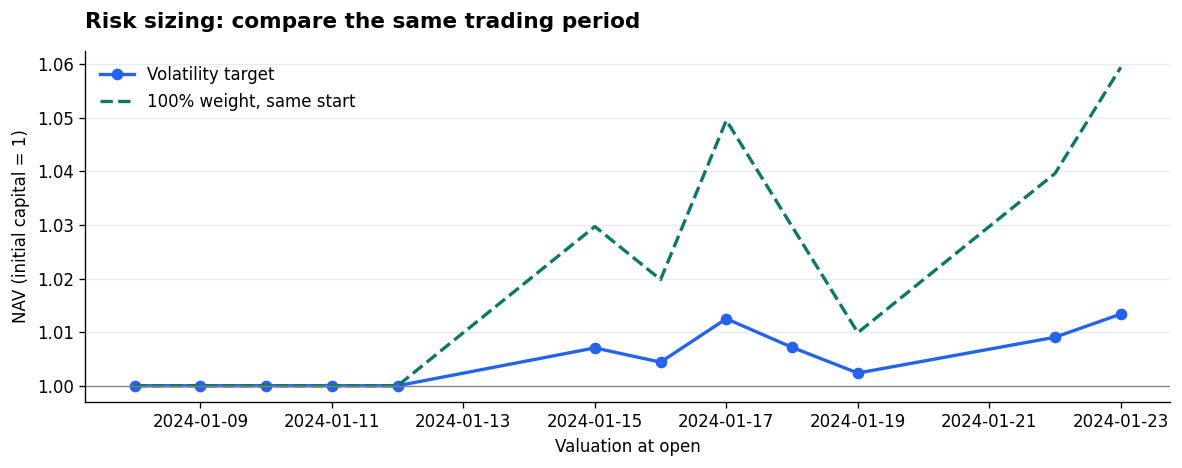

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(result.index, result['nav'], color=BLUE, marker='o', label='Volatility target')
plt.plot(result.index, result['fixed_nav'], color=TEAL, linestyle='--', label='100% weight, same start')
plt.axhline(1, color='grey', linewidth=0.8)
plt.title('Risk sizing: compare the same trading period')
plt.xlabel('Valuation at open')
plt.ylabel('NAV (initial capital = 1)')
plt.legend()
plt.tight_layout()
plt.show()

**怎么看：** 先在结果表核对 estimated_vol → weight_at_close → holding 的两行延迟，再看风险控制是否改变净值路径。收益不一定提高。

**换数据时注意：** 这是无成本、每日开盘再平衡的 long-only 演示；现金收益为 0。252 只适用于已核对的交易日日频。最后两行收盘权重没有完整的后续开盘到开盘收益，不把它们补成盈利或亏损。

<a id='B14'></a>
## B14 · 样本外回测：训练集定候选、验证集选阈值、测试集只评一次

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [41]:
df = pd.DataFrame({
    'open': [100.0] * 18,
    'close': [101, 99, 102, 98, 101, 100, 102, 99, 101,
              98, 103, 101, 99, 102, 98, 101, 100, 103],
    'score_before_open': [0.2, -0.5, 0.8, -0.9, 0.4, -0.1,
                          0.7, -0.2, 0.6, -0.8, 0.9, 0.3,
                          0.8, 0.4, -0.7, -0.3, 0.1, 0.9],
    'split': ['train'] * 6 + ['validation'] * 6 + ['test'] * 6,
}, index=pd.bdate_range('2024-01-08', periods=18))
display(df)

,open,close,score_before_open,split
2024-01-08,100.0,101,0.2,train
2024-01-09,100.0,99,-0.5,train
2024-01-10,100.0,102,0.8,train
2024-01-11,100.0,98,-0.9,train
2024-01-12,100.0,101,0.4,train
2024-01-15,100.0,100,-0.1,train
2024-01-16,100.0,102,0.7,validation
2024-01-17,100.0,99,-0.2,validation
2024-01-18,100.0,101,0.6,validation
2024-01-19,100.0,98,-0.8,validation


**场景 / 要做什么：**

**场景：** 已有盘前可用的预测分数，想测试“分数大于阈值做多、小于负阈值做空，否则空仓”。`split` 是事先划好的连续时间区间。

**要做什么：** 用训练分数生成 3 个候选阈值，只在验证集比较；锁定阈值后算测试集净收益。每天开盘建仓、收盘全部平仓，因此本例没有跨边界持仓，也没有重叠多日标签。输入分数为手工演示；真实模型必须在生成每个分数之前完成训练，标准化也只能拟合历史训练数据。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [42]:
result = df.sort_index().copy()
assert result.index.is_unique
assert np.isfinite(result[['open', 'close', 'score_before_open']]).all().all()
assert (result[['open', 'close']] > 0).all().all()
assert set(result['split']) == {'train', 'validation', 'test'}
train = result['split'].eq('train')
valid = result['split'].eq('validation')
test = result['split'].eq('test')
assert result.index[train].max() < result.index[valid].min()
assert result.index[valid].max() < result.index[test].min()
result['asset_return'] = result['close'] / result['open'] - 1
fee_rate, gross_weight = 5 / 10000, 0.8
candidates = np.unique(result.loc[train, 'score_before_open'].abs().quantile([0.25, 0.5, 0.75]))
rows = []
for threshold in candidates:
    score = result.loc[valid, 'score_before_open']
    weight = np.sign(score) * score.abs().gt(threshold) * gross_weight
    r = result.loc[valid, 'asset_return']
    # 每天都开平仓：入场名义金额 |w|，出场名义金额 |w|*(1+r)。
    net = weight * r - fee_rate * weight.abs() * (2 + r)
    assert (net > -1).all()
    rows.append([threshold, (1 + net).prod() - 1])
selection = pd.DataFrame(rows, columns=['threshold', 'validation_net_return'])
best_threshold = selection.loc[selection['validation_net_return'].idxmax(), 'threshold']
# 到这里才使用 test 的实际收益；同分时使用候选列表中较小的阈值。
oos = result.loc[test].copy()
score = oos['score_before_open']
oos['weight'] = np.sign(score) * score.abs().gt(best_threshold) * gross_weight
oos['cost'] = fee_rate * oos['weight'].abs() * (2 + oos['asset_return'])
oos['strategy_return'] = oos['weight'] * oos['asset_return'] - oos['cost']
assert (oos['strategy_return'] > -1).all()
oos['nav'] = (1 + oos['strategy_return']).cumprod()
display(selection.round(4))
print('Locked threshold:', round(best_threshold, 4))
display(oos.round(4))

,threshold,validation_net_return
0,0.250,0.0698
1,0.450,0.0621
2,0.725,0.0387


Locked threshold: 0.25


,open,close,score_before_open,split,asset_return,weight,cost,strategy_return,nav
2024-01-24,100.0,99,0.8,test,-0.01,0.8,0.0008,-0.0088,0.9912
2024-01-25,100.0,102,0.4,test,0.02,0.8,0.0008,0.0152,1.0063
2024-01-26,100.0,98,-0.7,test,-0.02,-0.8,0.0008,0.0152,1.0216
2024-01-29,100.0,101,-0.3,test,0.01,-0.8,0.0008,-0.0088,1.0126
2024-01-30,100.0,100,0.1,test,0.00,0.0,0.0000,0.0000,1.0126
2024-01-31,100.0,103,0.9,test,0.03,0.8,0.0008,0.0232,1.0361


**可视化：** 直接使用刚刚算出的结果。

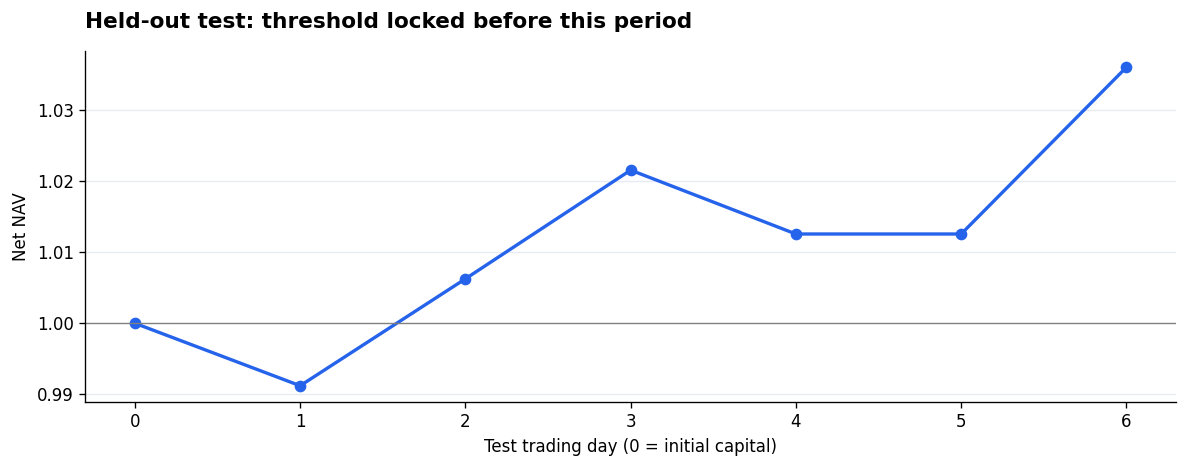

In [43]:
# 用第0期本金作起点，避免把测试首日亏损藏掉。
x = np.arange(len(oos) + 1)
plt.figure(figsize=(10, 4))
plt.plot(x, np.r_[1, oos['nav'].to_numpy()], color=BLUE, marker='o')
plt.axhline(1, color='grey', linewidth=0.8)
plt.title('Held-out test: threshold locked before this period')
plt.xlabel('Test trading day (0 = initial capital)')
plt.ylabel('Net NAV')
plt.tight_layout()
plt.show()

**怎么看：** 验证集表用于选参数，图只画锁定参数后的测试净值。即使测试表现不好，也先报告结果，再把新想法留给新的未见样本。

**换数据时注意：** 本例允许做空，忽略借券费、保证金、滑点与成交容量；fee_rate 为单边费率。训练/验证/测试各 6 行只展示流程，不能说明泛化能力。若改成 h 日标签，应按标签结束/可用时间 purge 跨边界样本；不能只按特征日期切分。

<a id='B15'></a>
## B15 · 绩效表与回撤：从每日净收益计算，不漏掉首日亏损

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [44]:
df = pd.DataFrame({
    'strategy_return': [-0.02, 0.01, 0.015, -0.03, 0.01, -0.01,
                         0.025, 0.015, -0.005, 0.01, 0.005, -0.01],
}, index=pd.bdate_range('2024-01-08', periods=12))
display(df)

,strategy_return
2024-01-08,-0.020
2024-01-09,0.010
2024-01-10,0.015
2024-01-11,-0.030
2024-01-12,0.010
2024-01-15,-0.010
2024-01-16,0.025
2024-01-17,0.015
2024-01-18,-0.005
2024-01-19,0.010


**场景 / 要做什么：**

**场景：** 已经得到每个交易日的账户净收益 `strategy_return`（已扣本策略应计成本；空仓日也有一行）。

**要做什么：** 给出累计收益、按 252 期口径的几何年化收益、波动、Sharpe、最大回撤、最长水下期数和上涨日比例，再画回撤。首日亏损必须相对于初始净值 1 计算。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [45]:
result = df.sort_index().copy()
assert result.index.is_unique
r = result['strategy_return']
assert len(r) >= 2 and np.isfinite(r).all() and (r > -1).all()
periods_per_year, risk_free_annual = 252, 0.0
rf_per_day = (1 + risk_free_annual) ** (1 / periods_per_year) - 1
result['nav'] = (1 + r).cumprod()
result['high_watermark'] = result['nav'].cummax().clip(lower=1)
result['drawdown'] = result['nav'] / result['high_watermark'] - 1
underwater = result['drawdown'].lt(-1e-12)
# 连续水下“观测期数”，并非自然日；尚未恢复的最后一段也计入。
result['underwater_periods'] = underwater.groupby((~underwater).cumsum()).cumsum()
annual_return = result['nav'].iloc[-1] ** (periods_per_year / len(r)) - 1
annual_vol = r.std(ddof=1) * np.sqrt(periods_per_year)
sharpe = (r - rf_per_day).mean() / r.std(ddof=1) * np.sqrt(periods_per_year) if r.std(ddof=1) > 0 else np.nan
max_drawdown = result['drawdown'].min()
summary = pd.DataFrame({
    'value': [len(r), result['nav'].iloc[-1] - 1, annual_return, annual_vol,
              sharpe, max_drawdown, result['underwater_periods'].max(), (r > 0).mean()],
    'unit': ['periods', 'decimal return', 'decimal / year', 'decimal / sqrt(year)',
             'ratio', 'decimal', 'periods', 'fraction of ALL days'],
}, index=['observations', 'total_return', 'annualized_return', 'annualized_volatility',
          'Sharpe', 'max_drawdown', 'longest_underwater', 'positive_day_fraction'])
display(summary.round(4))
display(result.round(4))

,value,unit
observations,12.0000,periods
total_return,0.0136,decimal return
annualized_return,0.3287,decimal / year
annualized_volatility,0.2580,decimal / sqrt(year)
Sharpe,1.2208,ratio
max_drawdown,-0.0301,decimal
longest_underwater,4.0000,periods
positive_day_fraction,0.5833,fraction of ALL days


,strategy_return,nav,high_watermark,drawdown,underwater_periods
2024-01-08,-0.020,0.9800,1.0000,-0.0200,1
2024-01-09,0.010,0.9898,1.0000,-0.0102,2
2024-01-10,0.015,1.0046,1.0046,0.0000,0
2024-01-11,-0.030,0.9745,1.0046,-0.0300,1
2024-01-12,0.010,0.9843,1.0046,-0.0203,2
2024-01-15,-0.010,0.9744,1.0046,-0.0301,3
2024-01-16,0.025,0.9988,1.0046,-0.0058,4
2024-01-17,0.015,1.0138,1.0138,0.0000,0
2024-01-18,-0.005,1.0087,1.0138,-0.0050,1
2024-01-19,0.010,1.0188,1.0188,0.0000,0


**可视化：** 直接使用刚刚算出的结果。

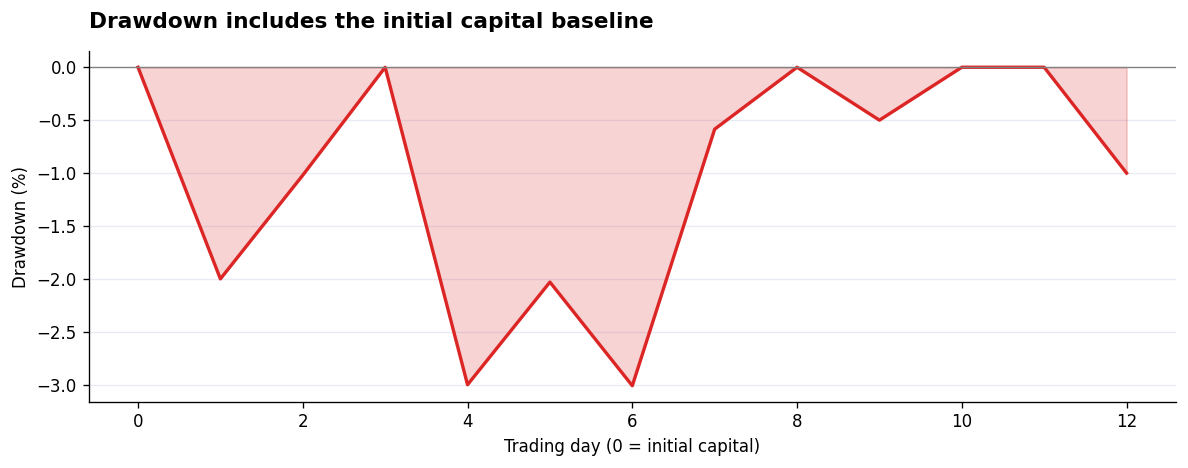

In [46]:
x = np.arange(len(result) + 1)
drawdown_pct = np.r_[0, result['drawdown'].to_numpy() * 100]
plt.figure(figsize=(10, 4))
plt.fill_between(x, drawdown_pct, 0, color=RED, alpha=0.20)
plt.plot(x, drawdown_pct, color=RED)
plt.axhline(0, color='grey', linewidth=0.8)
plt.title('Drawdown includes the initial capital baseline')
plt.xlabel('Trading day (0 = initial capital)')
plt.ylabel('Drawdown (%)')
plt.tight_layout()
plt.show()

**怎么看：** 先看样本长度、总收益和最大回撤。第一天跌 2%，回撤就是 −2%，不能因为第一天成了 cummax 的起点而显示 0。上涨日比例是按天统计，不能称为每笔交易胜率。

**换数据时注意：** 12 个合成日只用来演示计算，年化数字极不稳定。这里的年化收益按 252 个观测期缩放，不是自然日 CAGR；若观测不规则，先建立完整每日权益序列。sqrt(252) 是常见尺度换算，有自相关时 Sharpe 的这种年化可能失真；不能视为显著性检验。

<a id='B16'></a>
## B16 · 月度收益热图：空白月份与未结束月份分开处理

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [47]:
df = pd.DataFrame({
    'date': pd.to_datetime(['2024-01-30', '2024-01-31', '2024-02-01', '2024-02-29',
                            '2024-03-01', '2024-03-28', '2024-04-01', '2024-04-12']),
    'strategy_return': [0.01, -0.005, 0.015, 0.003, -0.02, 0.005, 0.012, -0.003],
    'month_complete': [False, False, True, True, True, True, False, False],
})
display(df)

,date,strategy_return,month_complete
0,2024-01-30,0.010,False
1,2024-01-31,-0.005,False
2,2024-02-01,0.015,True
3,2024-02-29,0.003,True
4,2024-03-01,-0.020,True
5,2024-03-28,0.005,True
6,2024-04-01,0.012,False
7,2024-04-12,-0.003,False


**场景 / 要做什么：**

**场景：** 把已经得到的每日净收益做月度汇报。`month_complete` 必须根据外部交易日历和采集覆盖范围事先确定，同一个月应一致；不能从“该月恰好有一条数据”推断完整。

**要做什么：** 月内用 `(1 + r).prod() - 1`，同时报告输入行数和完整性。热图用 `*` 标记部分月份，用灰格表示没有数据。本小表假设未列出的日子已验证为零收益，只为缩短展示；实际使用应提供完整逐日净收益表，不能擅自省略未知日。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [48]:
result = df.copy()
result['date'] = pd.to_datetime(result['date'])
result = result.sort_values('date').set_index('date')
assert result.index.is_unique
assert np.isfinite(result['strategy_return']).all()
assert (result['strategy_return'] > -1).all()
assert result['month_complete'].notna().all()
assert result['month_complete'].isin([True, False]).all()
month_key = result.index.to_period('M')
assert result.groupby(month_key)['month_complete'].nunique().eq(1).all()
monthly = result.groupby(month_key).agg(
    monthly_return=('strategy_return', lambda r: (1 + r).prod() - 1),
    shown_rows=('strategy_return', 'size'),
    complete=('month_complete', 'first'),
)
monthly['year'] = monthly.index.year
monthly['month'] = monthly.index.month
heat = monthly.pivot(index='year', columns='month', values='monthly_return').reindex(columns=range(1, 13))
complete = monthly.pivot(index='year', columns='month', values='complete').reindex(columns=range(1, 13))
display(monthly.round(4))

,monthly_return,shown_rows,complete,year,month
date,,,,,
2024-01,0.0050,2,False,2024,1
2024-02,0.0180,2,True,2024,2
2024-03,-0.0151,2,True,2024,3
2024-04,0.0090,2,False,2024,4


**可视化：** 直接使用刚刚算出的结果。

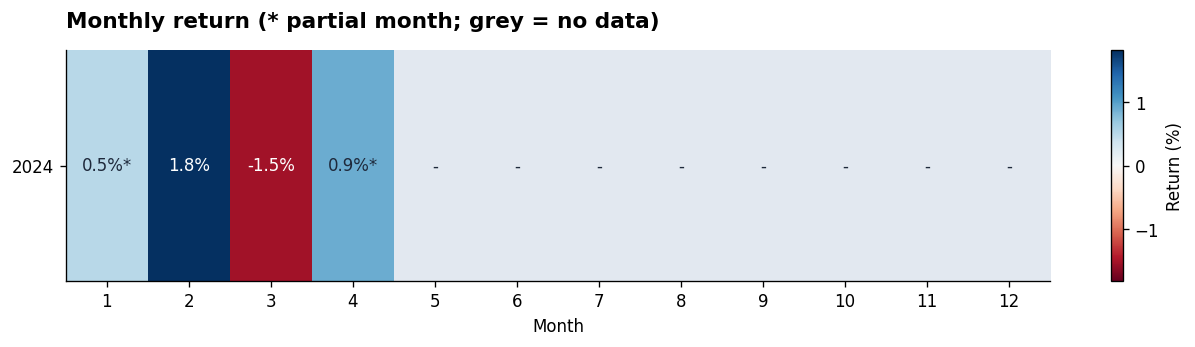

In [49]:
values = heat.to_numpy(dtype=float) * 100
limit = max(np.nanmax(np.abs(values)), 0.01)
cmap = plt.get_cmap('RdBu').copy()
cmap.set_bad('#E2E8F0')
plt.figure(figsize=(11, 3))
plt.imshow(values, cmap=cmap, vmin=-limit, vmax=limit, aspect='auto')
plt.grid(False)
plt.xticks(range(12), range(1, 13))
plt.yticks(range(len(heat)), heat.index)
for row in range(len(heat)):
    for col in range(12):
        value = values[row, col]
        label = '-' if np.isnan(value) else '{:.1f}%{}'.format(value, '' if complete.iloc[row, col] else '*')
        color = 'white' if np.isfinite(value) and abs(value) > 0.6 * limit else '#1E293B'
        plt.text(col, row, label, ha='center', va='center', color=color)
plt.colorbar(label='Return (%)')
plt.title('Monthly return (* partial month; grey = no data)')
plt.xlabel('Month')
plt.tight_layout()
plt.show()

**怎么看：** 完整月份和部分月份不能直接比较；没有数据的月份显示灰格，不显示为零收益。shown_rows 是本输入表的行数，不是经过日历确认的实际交易日总数。

**换数据时注意：** 本案例用小表说明聚合与画图。实际缺失一整天时，groupby 不会自动报错；必须先按真实会话日历检查覆盖，不能用普通 bdate_range 冒充交易所日历。

<a id='B17'></a>
## B17 · 策略与基准：净值比较、主动收益与滚动风险

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [50]:
df = pd.DataFrame({
    'strategy_return': [0.01, -0.005, 0.012, 0, -0.01, 0.02, -0.004, 0.008, 0.003, -0.007],
    'benchmark_return': [0.008, -0.01, 0.015, 0.004, -0.012, 0.016, -0.006, 0.006, 0.007, -0.003],
}, index=pd.bdate_range('2024-01-08', periods=10))
display(df)

,strategy_return,benchmark_return
2024-01-08,0.010,0.008
2024-01-09,-0.005,-0.010
2024-01-10,0.012,0.015
2024-01-11,0.000,0.004
2024-01-12,-0.010,-0.012
2024-01-15,0.020,0.016
2024-01-16,-0.004,-0.006
2024-01-17,0.008,0.006
2024-01-18,0.003,0.007
2024-01-19,-0.007,-0.003


**场景 / 要做什么：**

**场景：** 比较同一时间区间、同一估值时点的策略净收益与基准总收益。两列需要是相同单位、相同日历，不能一个是日收益、另一个是累计收益。

**要做什么：** 计算两条净值、相对财富 `strategy_nav / benchmark_nav`、每日主动收益和滚动跟踪误差。图画同一起点的净值，表中补充滚动风险；窗口 3 天只用于展示。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [51]:
result = df.sort_index().copy()
columns = ['strategy_return', 'benchmark_return']
assert result.index.is_unique
assert np.isfinite(result[columns]).all().all()
assert (result[columns] > -1).all().all()
window, periods_per_year = 3, 252
result['strategy_nav'] = (1 + result['strategy_return']).cumprod()
result['benchmark_nav'] = (1 + result['benchmark_return']).cumprod()
result['relative_wealth'] = result['strategy_nav'] / result['benchmark_nav']
result['active_return'] = result['strategy_return'] - result['benchmark_return']
result['rolling_vol'] = result['strategy_return'].rolling(window).std(ddof=1) * np.sqrt(periods_per_year)
result['rolling_tracking_error'] = result['active_return'].rolling(window).std(ddof=1) * np.sqrt(periods_per_year)
active_std = result['active_return'].std(ddof=1)
information_ratio = result['active_return'].mean() / active_std * np.sqrt(periods_per_year) if active_std > 0 else np.nan
display(result.round(4))
display(pd.DataFrame({'value': [result['relative_wealth'].iloc[-1] - 1, information_ratio]},
                     index=['relative_wealth_gain', 'annualized_information_ratio']).round(4))

,strategy_return,benchmark_return,strategy_nav,benchmark_nav,relative_wealth,active_return,rolling_vol,rolling_tracking_error
2024-01-08,0.010,0.008,1.0100,1.0080,1.0020,0.002,NaN,NaN
2024-01-09,-0.005,-0.010,1.0050,0.9979,1.0070,0.005,NaN,NaN
2024-01-10,0.012,0.015,1.0170,1.0129,1.0041,-0.003,0.1475,0.0642
2024-01-11,0.000,0.004,1.0170,1.0169,1.0001,-0.004,0.1387,0.0783
2024-01-12,-0.010,-0.012,1.0068,1.0047,1.0021,0.002,0.1749,0.0510
2024-01-15,0.020,0.016,1.0270,1.0208,1.0060,0.004,0.2425,0.0661
2024-01-16,-0.004,-0.006,1.0229,1.0147,1.0081,0.002,0.2520,0.0183
2024-01-17,0.008,0.006,1.0311,1.0208,1.0101,0.002,0.1905,0.0183
2024-01-18,0.003,0.007,1.0341,1.0279,1.0061,-0.004,0.0957,0.0550
2024-01-19,-0.007,-0.003,1.0269,1.0248,1.0020,-0.004,0.1212,0.0550


,value
relative_wealth_gain,0.0020
annualized_information_ratio,0.8936


**可视化：** 直接使用刚刚算出的结果。

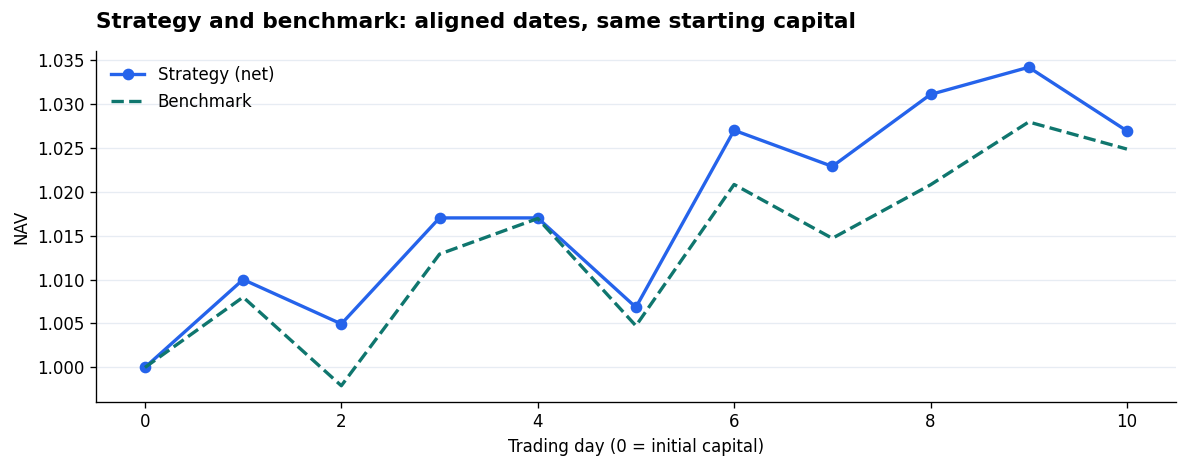

In [52]:
x = np.arange(len(result) + 1)
plt.figure(figsize=(10, 4))
plt.plot(x, np.r_[1, result['strategy_nav'].to_numpy()], color=BLUE, marker='o', label='Strategy (net)')
plt.plot(x, np.r_[1, result['benchmark_nav'].to_numpy()], color=TEAL, linestyle='--', label='Benchmark')
plt.title('Strategy and benchmark: aligned dates, same starting capital')
plt.xlabel('Trading day (0 = initial capital)')
plt.ylabel('NAV')
plt.legend()
plt.tight_layout()
plt.show()

**怎么看：** 策略净值更高说明这段样本累计财富更高；rolling_tracking_error 衡量主动收益的波动。relative_wealth 准确表示两条累计财富之比，不能用 (1 + active_return).cumprod() 代替它。

**换数据时注意：** 基准收益应与策略的币种、分红、估值时点匹配；例中基准为无额外交易成本的参考指数。图不能证明 alpha，10 天也不足以支持稳定性判断。不要用 inner join 静默删去策略亏损日或基准缺失日。

<a id='B18'></a>
## B18 · 费用敏感性：同一交易计划在不同单边费率下重算账户

**先看输入 DataFrame。** 下面的建表代码仅用来演示；替换成自己的同结构 `df` 后，先 display 再做回测。

In [53]:
df = pd.DataFrame({
    'price': [100, 102, 101, 103, 99, 101, 102, 100],
    'trade_shares': [5, 0, -5, 4, 0, -4, 3, -3],
}, index=pd.bdate_range('2024-01-08', periods=8))
display(df)

,price,trade_shares
2024-01-08,100,5
2024-01-09,102,0
2024-01-10,101,-5
2024-01-11,103,4
2024-01-12,99,0
2024-01-15,101,-4
2024-01-16,102,3
2024-01-17,100,-3


**场景 / 要做什么：**

**场景：** 已经有成交股数计划：`trade_shares > 0` 买入、`< 0` 卖出、`0` 不交易，指令在对应成交价可交易之前已知。本例先把交易计划固定，单独观察费用影响。

**要做什么：** 对 0、5、10、20 bps 单边费用重算现金/股票账户，画最终累计收益对费率的敏感性。每笔费用等于 `abs(成交股数 × 成交价) × 单边费率`，卖出同样扣费。

**回测代码：** 同时展示中间列或账户结果，方便逐行核对。

In [54]:
result = df.sort_index().copy()
assert result.index.is_unique
assert np.isfinite(result[['price', 'trade_shares']]).all().all()
assert (result['price'] > 0).all()
initial_cash = 1000.0
fee_grid_bps = [0, 5, 10, 20]
equity_paths, rows = {}, []
for bps in fee_grid_bps:
    cash, shares, total_fees = initial_cash, 0.0, 0.0
    history = []
    for row in result.itertuples():
        trade_value = row.trade_shares * row.price
        fee = abs(trade_value) * bps / 10000
        cash -= trade_value + fee
        shares += row.trade_shares
        if cash < -1e-8 or shares < -1e-8:
            raise ValueError('该费用下计划不可执行：现金不足或出现卖空')
        equity = cash + shares * row.price
        total_fees += fee
        history.append(equity)
    equity_paths[str(bps) + ' bps'] = history
    rows.append([bps, total_fees, equity / initial_cash - 1])
equity_paths = pd.DataFrame(equity_paths, index=result.index)
sensitivity = pd.DataFrame(rows, columns=['fee_bps_one_way', 'total_fees', 'total_return'])
display(sensitivity.round(4))
display(equity_paths.round(2))

,fee_bps_one_way,total_fees,total_return
0,0,0.0000,-0.0090
1,5,1.2135,-0.0102
2,10,2.4270,-0.0114
3,20,4.8540,-0.0139


,0 bps,5 bps,10 bps,20 bps
2024-01-08,1000.0,999.75,999.50,999.00
2024-01-09,1010.0,1009.75,1009.50,1009.00
2024-01-10,1005.0,1004.50,1004.00,1002.99
2024-01-11,1005.0,1004.29,1003.58,1002.17
2024-01-12,989.0,988.29,987.58,986.17
2024-01-15,997.0,996.09,995.18,993.36
2024-01-16,997.0,995.94,994.87,992.75
2024-01-17,991.0,989.79,988.57,986.15


**可视化：** 直接使用刚刚算出的结果。

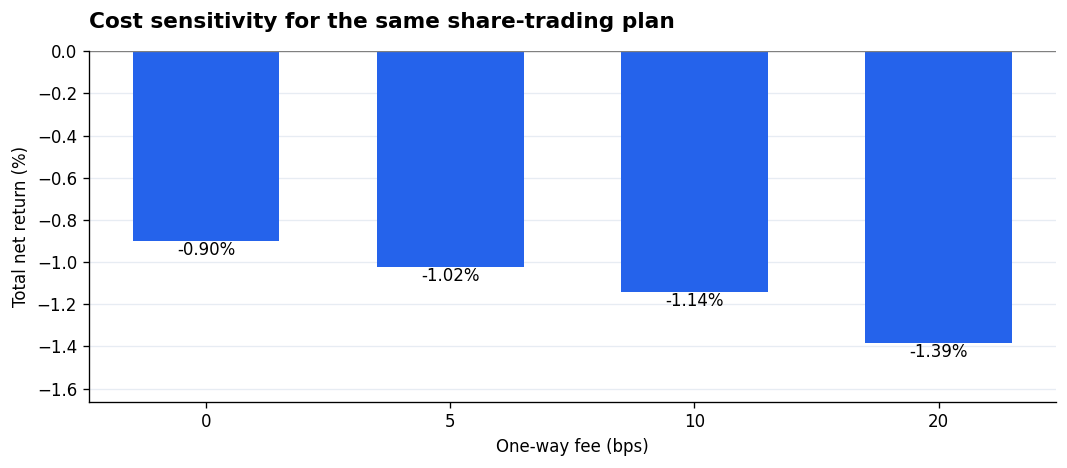

In [55]:
values = sensitivity['total_return'] * 100
plt.figure(figsize=(9, 4))
plt.bar(sensitivity['fee_bps_one_way'].astype(str), values, color=BLUE, width=0.6)
for i, value in enumerate(values):
    plt.text(i, value, '{:.2f}%'.format(value), ha='center', va='bottom' if value >= 0 else 'top')
plt.axhline(0, color='grey', linewidth=0.8)
plt.margins(y=0.2)
plt.title('Cost sensitivity for the same share-trading plan')
plt.xlabel('One-way fee (bps)')
plt.ylabel('Total net return (%)')
plt.tight_layout()
plt.show()

**怎么看：** 交易计划固定时，费用越高，最终资金越少。首笔买入和最后卖出都在费用中；最后一行确实把持仓清零，所以这里没有尚未计提的平仓费。

**换数据时注意：** 这是固定成交股数计划的反事实成本比较。若策略按账户权益重新计算仓位，费用会改变之后的下单数量，应该对每种费率重新运行完整策略。它也不包含价格冲击、无法成交和融资费用。

## 复制前的快速对照

| 检查点 | 怎么判断 |
|---|---|
| 信号是不是未来信息？ | 找到生成信号所需的最后一个时间戳，必须早于成交；收盘后算出的信号不能在同一收盘无延迟成交。 |
| 第一笔与最后一笔记了什么？ | 初始持仓是否为0；建仓费是否计入；最后是按市值估值还是已经平仓；未结束区间不虚构收益。 |
| 缺失行情怎么办？ | 先查日历、停牌、退市、数据断档；不能用填0收益让问题消失。 |
| 长表是否对齐？ | 检查 `(date, asset)` 唯一性、共同估值时点和完整持仓资产，分组shift不能跨资产。 |
| 权重还是股数？ | 权重保持不变通常需要交易；股数保持不变时权重会随价格漂移。 |
| 费用按什么计算？ | 按买卖绝对成交金额，含首次建仓和实际平仓；不得把目标权重差当通用实际换手。 |
| 净值、PnL、收益率单位是否混淆？ | 固定投入用货币PnL累计；权益比例策略用实际账户收益复合。 |
| 能否年化？ | 先确认完整、规则的收益频率和足够样本；先把不规则记录变成按会话估值的权益序列。 |
| 是投资组合还是价格差？ | 双腿分别计算资金贡献；零附近的价差不能直接pct_change。 |
| 调参是否污染测试？ | 事先确定切分；候选和阈值选择不用测试收益；多期标签按可用时间清除跨界样本。 |

本册不模拟限价订单队列、停牌无法成交、借券供给、保证金强平或动态价格冲击。遇到这些数据，先给出执行假设再扩展账户记账，不能把不存在的成交当作已实现交易。

## 汇报时最少展示什么

1. 一张输入/对齐样例表：解释信号、成交价、实际持仓和收益各在哪个时点。
2. 策略与基准净值、回撤、成本和样本长度；将样本内与样本外分开标记。
3. 交易次数/金额、敞口和费用定义；按日上涨比例与按笔胜率分开说。
4. 一个稳定性检查：分时期、成本敏感性或参数邻域；描述限制和下一步验证。

**保存当前图：** 在对应 `plt.show()` 前加 `plt.savefig('backtest_chart.png', dpi=180, bbox_inches='tight')`。

API 对照：[pandas pct_change](https://pandas.pydata.org/pandas-docs/version/1.5/reference/api/pandas.Series.pct_change.html) · [pandas shift](https://pandas.pydata.org/pandas-docs/version/1.5/reference/api/pandas.DataFrame.shift.html) · [Matplotlib pyplot](https://matplotlib.org/3.7.5/tutorials/introductory/pyplot.html)

本文件沿用仓库中的既有文件名，内容已从预留页更新为回测与可视化手册。